<a href="https://colab.research.google.com/github/sarahec702-afk/Code/blob/main/Copy_of_Integrating_Inheritance_Model_Selection%2C_Weighted_Polygenic_Scoring%2C_and_Interpretable_Machine_Learning_for_Cardiotoxicity_Risk_Prediction_in_Pediatric_ALL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pharmacogenomic Analysis of Chemotherapy-Induced Cardiotoxicity in Pediatric ALL

**Dataset:** `Cardiotoxicity.xlsx` (n = 216 patients; B-ALL/T-ALL pediatric cohort)

This notebook performs a full pharmacogenomic association and predictive-modeling workflow:

1. Data loading & cleaning
2. Allele frequency calculation + Chi-square test (Cardiotoxicity vs no Cardiotoxicity)
3. Genotype frequency + 4 genetic inheritance models (Codominant, Dominant, Recessive, Additive) + AIC model selection
4. **Bonferroni correction** for multiple testing (allele-level + genotype-level tests)
5. Polygenic Risk Score (PRS) — 2 methods (unweighted additive vs. effect-weighted best-model) + AUC + **tertile dose-response analysis**
6. Logistic regression — demographic/anthropometric and genetic predictors of cardiotoxicity
7. Machine Learning models — Logistic Regression, SVM, XGBoost (**80:20 split**, MinMax-normalized features)
8. **Hyperparameter tuning with 5-fold cross-validation** (GridSearchCV)
9. Model evaluation graphs (ROC, confusion matrices, radar chart) + metrics
10. McNemar's test — statistical comparison of ML model performance
11. Summary table & key takeaways

> **How to use in Google Colab:** Upload `Cardiotoxicity.xlsx` using the file-upload cell in Section 0, then run all cells in order (`Runtime > Run all`).

> Every code cell below has inline comments explaining **why** each step is done, not just what it does — read the comments alongside the code if you're learning the workflow.


## 0. Setup — Install & Import Libraries

In [ ]:
# Install required packages (Colab usually has most of these pre-installed;
# this just pins/ensures the versions we need are present)
!pip install -q statsmodels scikit-learn xgboost matplotlib seaborn openpyxl scipy


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.multitest import multipletests          # Bonferroni / FDR correction
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, auc, confusion_matrix)
from statsmodels.stats.contingency_tables import mcnemar
import xgboost as xgb
from itertools import combinations
from math import pi
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# VISUAL IDENTITY
# ------------------------------------------------------------
# A deliberate, clinical-genomics palette instead of default matplotlib colors:
#   INK    -> near-black navy, used for all text/axes (higher contrast than pure black)
#   TEAL   -> "NO / safe" outcome color
#   CORAL  -> "YES / risk" outcome color
#   GOLD   -> accent/highlight color (used sparingly, e.g. tertile trend lines)
#   GREY   -> muted secondary text (subtitles, annotations)
#   BG     -> warm off-white background (less clinical/sterile than pure white)
# ============================================================
INK   = '#1A2332'
NAVY  = '#2C4870'
TEAL  = '#16A085'
CORAL = '#E8554E'
GOLD  = '#E8A23D'
GREY  = '#8B95A6'
BG    = '#FCFBF8'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': INK,
    'axes.linewidth': 1.1,
    'axes.labelcolor': INK,
    'text.color': INK,
    'xtick.color': INK,
    'ytick.color': INK,
    'figure.facecolor': BG,
    'axes.facecolor': BG,
    'axes.grid': True,
    'grid.color': '#E4E0D8',
    'grid.linewidth': 0.7,
    'grid.alpha': 0.8,
    'axes.axisbelow': True,
})
PALETTE = {'YES': CORAL, 'NO': TEAL}                 # outcome color mapping, reused across all charts
MODEL_COLORS = {'LogisticRegression': NAVY, 'SVM': GOLD, 'XGBoost': '#6A4C93'}

RANDOM_STATE = 42        # fixed seed everywhere so results are reproducible on re-run
np.random.seed(RANDOM_STATE)

print("Libraries loaded.")


Libraries loaded.


### Upload the dataset
Run the cell below and select `Cardiotoxicity.xlsx` from your computer. If you're not on Colab (e.g. running locally or the file is already in your working directory), skip this cell and just make sure `Cardiotoxicity.xlsx` is in the same folder as this notebook.

In [ ]:
try:
    # google.colab is only importable inside an actual Colab runtime,
    # so this block runs the file picker only when needed and is skipped otherwise.
    from google.colab import files
    uploaded = files.upload()  # select Cardiotoxicity.xlsx when prompted
    FILE_PATH = list(uploaded.keys())[0]
except ImportError:
    # Not running in Colab - assume the file is already present in the working directory
    FILE_PATH = 'Cardiotoxicity.xlsx'

print("Using file:", FILE_PATH)


Using file: Cardiotoxicity.xlsx


## 0.1 Load and Clean Data

The raw file has a few messy entries that need cleaning before analysis:
- `AGE` has stray spaces / inconsistent decimal entries (e.g. `'1 .2'`)
- `BALL/TALL` has inconsistent capitalization (e.g. `'ball'` vs `'BALL'`)
- All categorical text columns are stripped and upper-cased for consistent matching

All 216 rows are retained — no records are dropped.

In [ ]:
df = pd.read_excel(FILE_PATH)
print("Raw shape:", df.shape)
display(df.head())


Raw shape: (216, 10)


,Cardiotoxicity,GENDER,BALL/TALL,AGE,HISTORY OF CANCER,SOD2,PNPLA3,ABCC1,CBR1,ABCG2
0,YES,M,BALL,5,Y,TG,GC,TT,AA,AC
1,NO,F,BALL,4,Y,GG,CC,GG,AA,AA
2,NO,M,BALL,5,N,TT,GG,GG,GG,CC
3,YES,M,BALL,5,N,TT,CC,GT,AA,CC
4,NO,F,BALL,1 .2,Y,TT,GG,TT,AA,AA


In [ ]:
# Logic: AGE was read in as text because some cells contain stray whitespace
# (e.g. "1 .2" instead of "1.2"). Strip whitespace first, THEN convert to numeric -
# doing it in this order prevents pd.to_numeric from silently turning malformed entries into NaN.
df['AGE'] = df['AGE'].astype(str).str.strip().str.replace(' ', '', regex=False)
df['AGE'] = pd.to_numeric(df['AGE'], errors='coerce')

# Logic: every categorical column gets the same treatment (strip + uppercase)
# so that e.g. "ball" and "BALL" are treated as the same category, not two different ones.
for c in ['Cardiotoxicity', 'GENDER', 'BALL/TALL', 'HISTORY OF CANCER',
          'SOD2', 'PNPLA3', 'ABCC1', 'CBR1', 'ABCG2']:
    df[c] = df[c].astype(str).str.strip().str.upper()

print("Missing values after cleaning:\n", df.isnull().sum())
print("\nAGE summary:\n", df['AGE'].describe())
print("\nBALL/TALL categories:\n", df['BALL/TALL'].value_counts())

# Logic: binary-encode every categorical outcome/covariate now, once, so every later
# section (Chi-square, logistic regression, ML) reuses the exact same encoding -
# this avoids subtle inconsistencies from encoding the same column twice in different ways.
df['Cardiotox_bin']  = (df['Cardiotoxicity'] == 'YES').astype(int)
df['GENDER_bin']     = (df['GENDER'] == 'M').astype(int)            # 1 = Male, 0 = Female
df['ALL_TYPE_bin']   = (df['BALL/TALL'] == 'TALL').astype(int)      # 1 = T-ALL, 0 = B-ALL
df['HISTORY_bin']    = (df['HISTORY OF CANCER'] == 'Y').astype(int) # 1 = prior cancer hx

SNPS = ['SOD2', 'PNPLA3', 'ABCC1', 'CBR1', 'ABCG2']
print("\nSNPs analyzed:", SNPS)
df.head()


Missing values after cleaning:
 Cardiotoxicity       0
GENDER               0
BALL/TALL            0
AGE                  0
HISTORY OF CANCER    0
SOD2                 0
PNPLA3               0
ABCC1                0
CBR1                 0
ABCG2                0
dtype: int64

AGE summary:
 count    216.000000
mean       7.133843
std        3.782692
min        1.000000
25%        4.000000
50%        6.600000
75%       10.050000
max       15.000000
Name: AGE, dtype: float64

BALL/TALL categories:
 BALL/TALL
BALL    175
TALL     41
Name: count, dtype: int64

SNPs analyzed: ['SOD2', 'PNPLA3', 'ABCC1', 'CBR1', 'ABCG2']


,Cardiotoxicity,GENDER,BALL/TALL,AGE,HISTORY OF CANCER,SOD2,PNPLA3,ABCC1,CBR1,ABCG2,Cardiotox_bin,GENDER_bin,ALL_TYPE_bin,HISTORY_bin
0,YES,M,BALL,5.0,Y,TG,GC,TT,AA,AC,1,1,0,1
1,NO,F,BALL,4.0,Y,GG,CC,GG,AA,AA,0,0,0,1
2,NO,M,BALL,5.0,N,TT,GG,GG,GG,CC,0,1,0,0
3,YES,M,BALL,5.0,N,TT,CC,GT,AA,CC,1,1,0,0
4,NO,F,BALL,1.2,Y,TT,GG,TT,AA,AA,0,0,0,1


---
## 1. Allele Frequency Calculation & Chi-Square Test

For each SNP we:
1. Count alleles from genotypes (e.g. genotype `AG` contributes one `A` and one `G` allele)
2. Calculate allele frequencies overall and separately within the **Cardiotoxicity = YES** and **Cardiotoxicity = NO** groups
3. Run a **2×2 Chi-square test** (allele counts × cardiotoxicity status) to test whether allele distribution differs significantly between groups

*(Raw p-values here are uncorrected for multiple testing — the Bonferroni-corrected version is in Section 2.1, after the genotype-level tests are also run, so both families of tests are corrected together.)*

In [ ]:
def allele_counts(series, a1, a2):
    """Count alleles a1/a2 from a Series of 2-letter genotype strings.
    Logic: a genotype like 'AG' simply contains one count of 'A' and one of 'G' -
    str.count() on each genotype string and summing across patients gives total allele counts."""
    c1 = sum(g.count(a1) for g in series)
    c2 = sum(g.count(a2) for g in series)
    return c1, c2

allele_rows = []
for snp in SNPS:
    # Logic: determine the two alleles actually present for this SNP from the genotype letters themselves,
    # rather than hardcoding them, so the code generalizes to any biallelic SNP column.
    genos_present = df[snp].unique()
    letters = sorted(set(''.join(genos_present)))
    assert len(letters) == 2, f"{snp} is not biallelic: {letters}"
    a1, a2 = letters

    # Overall allele frequency across all 216 patients
    c1, c2 = allele_counts(df[snp], a1, a2)
    n_tot = c1 + c2
    f1, f2 = c1 / n_tot, c2 / n_tot
    # Logic: "major" allele = the more frequent one in the overall sample; "minor" = the less frequent one.
    # This convention (major/minor) is standard in genetics and used consistently in every later section.
    major, minor = (a1, a2) if f1 >= f2 else (a2, a1)

    # ── CBR1 biological correction ──────────────────────────────────────────
    # For CBR1, frequency-based assignment gives A=major (58.1%) and G=minor,
    # but the biologically correct reference is GG (normal) and AA (variant/mutant).
    # Override to match the established pharmacogenomic convention for this SNP.
    if snp == 'CBR1':
        major, minor = 'G', 'A'
    # ────────────────────────────────────────────────────────────────────────

    # Allele counts split by outcome group
    y1, y2 = allele_counts(df.loc[df['Cardiotoxicity'] == 'YES', snp], a1, a2)
    n1, n2 = allele_counts(df.loc[df['Cardiotoxicity'] == 'NO', snp], a1, a2)

    # Logic: 2x2 contingency table = rows are outcome groups (YES/NO), columns are allele counts (a1/a2).
    # correction=False uses the standard (non-Yates-corrected) Chi-square, appropriate for reasonably-sized cell counts.
    table = np.array([[y1, y2], [n1, n2]])
    chi2, p, dof, exp = stats.chi2_contingency(table, correction=False)

    allele_rows.append({
        'SNP': snp, 'Allele1': a1, 'Allele2': a2,
        'Freq_Allele1_overall': round(f1, 4), 'Freq_Allele2_overall': round(f2, 4),
        'Major_allele': major, 'Minor_allele': minor,
        'Allele1_count_YES': y1, 'Allele2_count_YES': y2,
        'Allele1_count_NO': n1, 'Allele2_count_NO': n2,
        'Chi2_statistic': round(chi2, 4), 'p_value': round(p, 4)
    })

allele_df = pd.DataFrame(allele_rows)
allele_df['Significant (p<0.05, uncorrected)'] = allele_df['p_value'] < 0.05
print("=== Allele Frequency & Chi-Square Test (Cardiotoxicity YES vs NO) ===")
display(allele_df)


=== Allele Frequency & Chi-Square Test (Cardiotoxicity YES vs NO) ===


,SNP,Allele1,Allele2,Freq_Allele1_overall,Freq_Allele2_overall,Major_allele,Minor_allele,Allele1_count_YES,Allele2_count_YES,Allele1_count_NO,Allele2_count_NO,Chi2_statistic,p_value,"Significant (p<0.05, uncorrected)"
0,SOD2,G,T,0.3125,0.6875,T,G,57,101,78,196,2.7004,0.1003,False
1,PNPLA3,C,G,0.6019,0.3981,C,G,88,70,172,102,2.0948,0.1478,False
2,ABCC1,G,T,0.6875,0.3125,G,T,105,53,192,82,0.6103,0.4347,False
3,CBR1,A,G,0.5810,0.4190,G,A,106,52,145,129,8.2644,0.0040,True
4,ABCG2,A,C,0.4398,0.5602,C,A,41,117,149,125,32.8762,0.0000,True


**Interpretation:** A significant uncorrected p-value (< 0.05) suggests the minor allele may be unevenly distributed between cardiotoxicity-positive and cardiotoxicity-negative patients. Whether this survives multiple-testing correction is checked in Section 2.1.

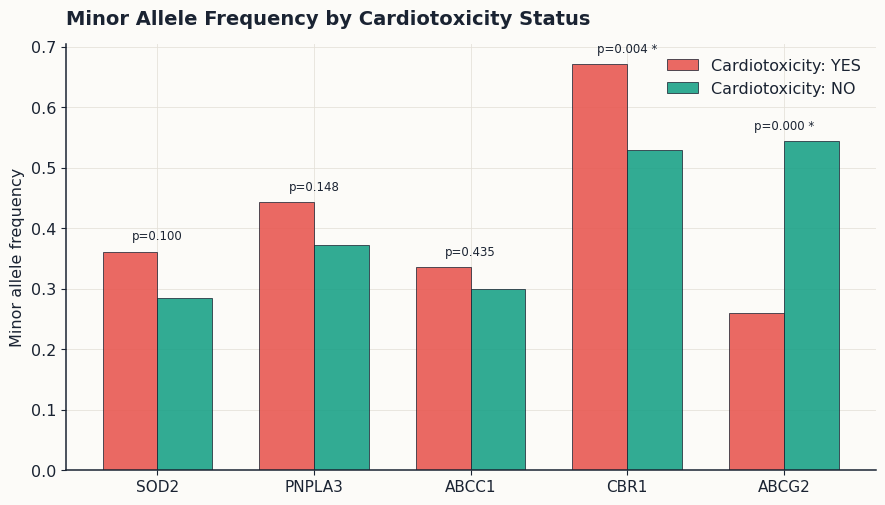

In [ ]:
# Chart logic: a grouped bar chart comparing minor allele frequency between the two outcome
# groups, with the Chi-square p-value annotated above each pair of bars, so the visual and
# the statistic are read together rather than needing a separate table lookup.
fig, ax = plt.subplots(figsize=(9, 5.2))
x = np.arange(len(allele_df))
width = 0.35
minor_freq_yes, minor_freq_no = [], []
for _, row in allele_df.iterrows():
    minor = row['Minor_allele']
    a1, a2 = row['Allele1'], row['Allele2']
    y1, y2 = row['Allele1_count_YES'], row['Allele2_count_YES']
    n1, n2 = row['Allele1_count_NO'], row['Allele2_count_NO']
    if minor == a1:
        minor_freq_yes.append(y1 / (y1 + y2)); minor_freq_no.append(n1 / (n1 + n2))
    else:
        minor_freq_yes.append(y2 / (y1 + y2)); minor_freq_no.append(n2 / (n1 + n2))

ax.bar(x - width/2, minor_freq_yes, width, label='Cardiotoxicity: YES', color=CORAL, alpha=0.88, edgecolor=INK, linewidth=0.6)
ax.bar(x + width/2, minor_freq_no, width, label='Cardiotoxicity: NO', color=TEAL, alpha=0.88, edgecolor=INK, linewidth=0.6)
ax.set_xticks(x); ax.set_xticklabels(allele_df['SNP'], fontsize=11)
ax.set_ylabel('Minor allele frequency')
ax.set_title('Minor Allele Frequency by Cardiotoxicity Status', fontsize=14, fontweight='bold', loc='left', pad=14)
for i, p in enumerate(allele_df['p_value']):
    sig = ' *' if p < 0.05 else ''
    ax.text(i, max(minor_freq_yes[i], minor_freq_no[i]) + 0.02, f'p={p:.3f}{sig}', ha='center', fontsize=8.5, color=INK)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


---
## 2. Genotype Frequency, Chi-Square & 4 Genetic Inheritance Models

For each SNP, genotypes are labeled **Hom-major** (both major alleles), **Het** (heterozygous), **Hom-minor** (both minor alleles).

We then test **4 standard genetic inheritance models** (the conventional set used in tools like SNPStats/PLINK), each as a separate logistic regression of `Cardiotoxicity ~ genotype-coded-predictor`:

| Model | Coding |
|---|---|
| **Codominant** | 3 separate groups (Hom-major / Het / Hom-minor), no assumed direction |
| **Dominant** | Hom-major vs (Het + Hom-minor) |
| **Recessive** | (Hom-major + Het) vs Hom-minor |
| **Additive (log-additive)** | Minor allele count: 0 / 1 / 2 (linear dose-response) |

The **AIC (Akaike Information Criterion)** of each model is compared — the model with the **lowest AIC** is the best-fitting inheritance pattern for that SNP (AIC penalizes extra parameters, so the 3-parameter Codominant model only "wins" if it earns that complexity with real improvement in fit).

A single consolidated table (genotype counts + group percentages + Chi-square p-value, all in one place) is used instead of a genotype bar chart — with the numeric values already laid out per SNP, a bar chart of the same numbers adds a picture without adding new information.

In [ ]:
genotype_freq_rows = []
genotype_chisq_rows = []
model_fit_rows = []
model_coding_store = {}  # snp -> info dict, reused later for PRS and logistic regression sections

for snp in SNPS:
    arow = allele_df.set_index('SNP').loc[snp]
    major, minor = arow['Major_allele'], arow['Minor_allele']

    # ── CBR1 biological correction ──────────────────────────────────────────
    # The frequency-based major/minor assignment sets A as major (58.1%) and
    # G as minor (41.9%), which is statistically correct but biologically wrong.
    # For CBR1 (rs9024), GG is the reference (normal) genotype and AA is the
    # variant (mutant) genotype — this is the established pharmacogenomic
    # convention for this SNP. Swapping here ensures all downstream coding
    # (additive 0/1/2, dominant, recessive, codominant reference level, PRS
    # beta direction, and risk allele labelling) uses the correct orientation.
    if snp == 'CBR1':
        major, minor = 'G', 'A'   # GG = reference; AA = homozygous variant
    # ────────────────────────────────────────────────────────────────────────

    hom_major, hom_minor = major * 2, minor * 2
    # Logic: the heterozygote genotype label is whatever 2-letter string in the data
    # is neither the major-major nor minor-minor combination (handles 'AG' vs 'GA' ordering automatically).
    genos_present = df[snp].unique().tolist()
    het_candidates = [g for g in genos_present if g not in (hom_major, hom_minor)]
    het = het_candidates[0] if het_candidates else (major + minor)

    # ---- Genotype frequency (overall + by outcome group) ----
    overall_counts = df[snp].value_counts()
    yes_counts = df.loc[df['Cardiotox_bin'] == 1, snp].value_counts()
    no_counts  = df.loc[df['Cardiotox_bin'] == 0, snp].value_counts()
    n_total = len(df)
    for g in [hom_major, het, hom_minor]:
        genotype_freq_rows.append({
            'SNP': snp, 'Genotype': g,
            'Count_overall': int(overall_counts.get(g, 0)),
            'Freq_overall': round(overall_counts.get(g, 0) / n_total, 4),
            'Count_YES': int(yes_counts.get(g, 0)),
            'Count_NO': int(no_counts.get(g, 0)),
            'Pct_within_YES': round(yes_counts.get(g, 0) / yes_counts.sum() * 100, 1),
            'Pct_within_NO': round(no_counts.get(g, 0) / no_counts.sum() * 100, 1),
        })

    # ---- Genotype Chi-square: 3x2 contingency table (3 genotypes x 2 outcome groups) ----
    table = np.array([
        [yes_counts.get(hom_major, 0), yes_counts.get(het, 0), yes_counts.get(hom_minor, 0)],
        [no_counts.get(hom_major, 0),  no_counts.get(het, 0),  no_counts.get(hom_minor, 0)]
    ])
    chi2, p, dof, exp = stats.chi2_contingency(table, correction=False)
    genotype_chisq_rows.append({
        'SNP': snp, 'Chi2_genotype_3x2': round(chi2, 4), 'dof': dof, 'p_value_genotype': round(p, 4),
        'Hom_major': hom_major, 'Het': het, 'Hom_minor': hom_minor
    })

    # ---- 4 genetic models: each recodes the same genotype data under a different
    # biological assumption about how the minor allele confers risk, then fits a
    # simple logistic regression so AIC values are directly comparable across models. ----
    geno_map_additive = {hom_major: 0, het: 1, hom_minor: 2}
    tmp = df[[snp, 'Cardiotox_bin']].copy()
    tmp['geno_cat']  = pd.Categorical(tmp[snp], categories=[hom_major, het, hom_minor], ordered=False)
    tmp['dominant']  = (tmp[snp] != hom_major).astype(int)   # minor allele has an effect even as a single copy
    tmp['recessive'] = (tmp[snp] == hom_minor).astype(int)   # minor allele only matters in double dose
    tmp['additive']  = tmp[snp].map(geno_map_additive)       # each extra minor allele adds equal risk

    m_codom = smf.logit(f'Cardiotox_bin ~ C(geno_cat, Treatment(reference="{hom_major}"))', data=tmp).fit(disp=0)
    m_dom   = smf.logit('Cardiotox_bin ~ dominant', data=tmp).fit(disp=0)
    m_rec   = smf.logit('Cardiotox_bin ~ recessive', data=tmp).fit(disp=0)
    m_add   = smf.logit('Cardiotox_bin ~ additive', data=tmp).fit(disp=0)

    # Store the coded variables for reuse in the PRS and logistic regression sections below,
    # so genotype coding logic is written exactly once in the whole notebook.
    model_coding_store[snp] = {
        'major': major, 'minor': minor, 'hom_major': hom_major, 'het': het, 'hom_minor': hom_minor,
        'coded': {
            'dominant': tmp['dominant'].values, 'recessive': tmp['recessive'].values,
            'additive': tmp['additive'].values, 'codominant': tmp['geno_cat'].values
        }
    }

    for name, m in [('Codominant', m_codom), ('Dominant', m_dom), ('Recessive', m_rec), ('Additive', m_add)]:
        model_fit_rows.append({
            'SNP': snp, 'Model': name, 'AIC': round(m.aic, 3),
            'LogLikelihood': round(m.llf, 3), 'p_value_LRT': round(m.llr_pvalue, 4)
        })

genotype_freq_df  = pd.DataFrame(genotype_freq_rows)
genotype_chisq_df = pd.DataFrame(genotype_chisq_rows)
model_fit_df      = pd.DataFrame(model_fit_rows)

print("=== Genotype Frequency Table (counts, overall %, and within-group %) ===")
display(genotype_freq_df)
print("\n=== Genotype Chi-square (3x2 contingency table) ===")
display(genotype_chisq_df)


=== Genotype Frequency Table (counts, overall %, and within-group %) ===


,SNP,Genotype,Count_overall,Freq_overall,Count_YES,Count_NO,Pct_within_YES,Pct_within_NO
0,SOD2,TT,119,0.5509,37,82,46.8,59.9
1,SOD2,TG,59,0.2731,27,32,34.2,23.4
2,SOD2,GG,38,0.1759,15,23,19.0,16.8
3,PNPLA3,CC,112,0.5185,37,75,46.8,54.7
4,PNPLA3,GC,36,0.1667,14,22,17.7,16.1
5,PNPLA3,GG,68,0.3148,28,40,35.4,29.2
6,ABCC1,GG,123,0.5694,43,80,54.4,58.4
7,ABCC1,GT,51,0.2361,19,32,24.1,23.4
8,ABCC1,TT,42,0.1944,17,25,21.5,18.2
9,CBR1,GG,68,0.3148,21,47,26.6,34.3



=== Genotype Chi-square (3x2 contingency table) ===


,SNP,Chi2_genotype_3x2,dof,p_value_genotype,Hom_major,Het,Hom_minor
0,SOD2,3.8266,2,0.1476,TT,TG,GG
1,PNPLA3,1.3086,2,0.5198,CC,GC,GG
2,ABCC1,0.4241,2,0.8089,GG,GT,TT
3,CBR1,9.4102,2,0.0090,GG,GA,AA
4,ABCG2,45.7846,2,0.0000,CC,AC,AA


In [ ]:
print("=== 4-Model Comparison: AIC & Likelihood-Ratio p-value ===")
display(model_fit_df)

# Logic: groupby SNP, then take the row with the minimum AIC within each group -
# that row's "Model" column tells us the best-fitting inheritance pattern for that SNP.
best_models = model_fit_df.loc[model_fit_df.groupby('SNP')['AIC'].idxmin()].reset_index(drop=True)
print("\n=== Best-Fitting Genetic Model per SNP (lowest AIC) ===")
display(best_models)


=== 4-Model Comparison: AIC & Likelihood-Ratio p-value ===


,SNP,Model,AIC,LogLikelihood,p_value_LRT
0,SOD2,Codominant,285.871,-139.935,0.1494
1,SOD2,Dominant,284.245,-140.122,0.0641
2,SOD2,Recessive,287.507,-141.753,0.6839
3,SOD2,Additive,285.713,-140.856,0.1615
4,PNPLA3,Codominant,288.366,-141.183,0.5202
5,PNPLA3,Dominant,286.417,-141.208,0.2625
6,PNPLA3,Recessive,286.774,-141.387,0.3431
7,PNPLA3,Additive,286.410,-141.205,0.2612
8,ABCC1,Codominant,289.252,-141.626,0.8101
9,ABCC1,Dominant,287.352,-141.676,0.5713



=== Best-Fitting Genetic Model per SNP (lowest AIC) ===


,SNP,Model,AIC,LogLikelihood,p_value_LRT
0,ABCC1,Additive,287.254,-141.627,0.5177
1,ABCG2,Codominant,240.651,-117.325,0.0000
2,CBR1,Recessive,279.093,-137.546,0.0034
3,PNPLA3,Additive,286.410,-141.205,0.2612
4,SOD2,Dominant,284.245,-140.122,0.0641


**Why a heatmap instead of 4 separate bar charts?** Putting all 5 SNPs × 4 models in one heatmap lets you compare AIC across the *whole* grid at a glance — the lowest (greenest) cell in each row is the best model for that SNP — which is much harder to do by eye across 4-5 separate bar charts.

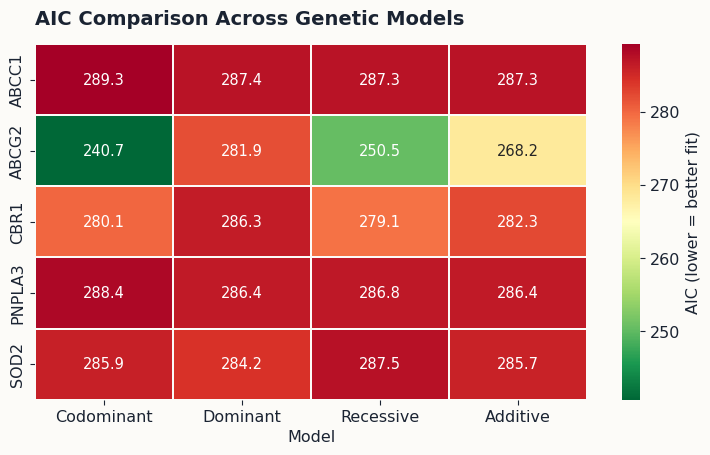

In [ ]:
# Chart logic: pivot to SNP x Model grid of AIC values, then color-map it -
# darker/cooler color = lower AIC = better fit, so the best model per row is visually obvious.
pivot = model_fit_df.pivot(index='SNP', columns='Model', values='AIC')[['Codominant', 'Dominant', 'Recessive', 'Additive']]
fig, ax = plt.subplots(figsize=(7.5, 4.7))
cmap = sns.color_palette([CORAL, '#F2C14E', TEAL][::-1], as_cmap=False)
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax,
            cbar_kws={'label': 'AIC (lower = better fit)'}, linewidths=1.2, linecolor=BG,
            annot_kws={'fontsize': 10.5})
ax.set_title('AIC Comparison Across Genetic Models', fontsize=14, fontweight='bold', loc='left', pad=14)
ax.set_ylabel('')
plt.tight_layout()
plt.show()


**Forest plot of additive-model odds ratios** — a forest plot conveys effect size *and* uncertainty (95% CI) in one view, which a simple OR bar chart can't.

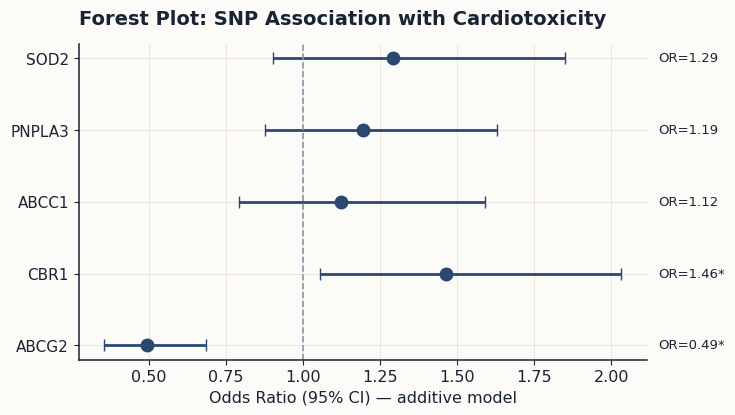

In [ ]:
forest_rows = []
for snp in SNPS:
    x = model_coding_store[snp]['coded']['additive']
    tmp = pd.DataFrame({'y': df['Cardiotox_bin'], 'x': x})
    m = smf.logit('y ~ x', data=tmp).fit(disp=0)
    ci = m.conf_int().loc['x']
    forest_rows.append({'SNP': snp, 'OR': np.exp(m.params['x']), 'lo': np.exp(ci[0]), 'hi': np.exp(ci[1]), 'p': m.pvalues['x']})
fp = pd.DataFrame(forest_rows)

fig, ax = plt.subplots(figsize=(7.5, 4.3))
yvals = np.arange(len(fp))[::-1]
ax.errorbar(fp['OR'], yvals, xerr=[fp['OR'] - fp['lo'], fp['hi'] - fp['OR']], fmt='o', color=NAVY,
            ecolor=NAVY, elinewidth=2, capsize=4, markersize=9)
ax.axvline(1, color=GREY, linestyle='--', linewidth=1.2)   # OR=1 reference line = "no effect"
ax.set_yticks(yvals); ax.set_yticklabels(fp['SNP'], fontsize=11)
ax.set_xlabel('Odds Ratio (95% CI) — additive model')
ax.set_title('Forest Plot: SNP Association with Cardiotoxicity', fontsize=14, fontweight='bold', loc='left', pad=14)
for yv, orv, p in zip(yvals, fp['OR'], fp['p']):
    sig = '*' if p < 0.05 else ''
    ax.text(fp['hi'].max() * 1.06, yv, f'OR={orv:.2f}{sig}', va='center', fontsize=9.5, color=INK)
plt.tight_layout()
plt.show()


---
### 2.1 Bonferroni Correction for Multiple Testing

We ran **10 hypothesis tests** in total: 5 SNPs × (1 allele-level Chi-square + 1 genotype-level Chi-square). Testing many hypotheses on the same outcome inflates the chance of a false positive — Bonferroni correction controls this by tightening the significance threshold to `α / number_of_tests`, the most conservative (and most widely reported) correction method.

A SNP that survives Bonferroni correction is a much stronger candidate finding than one that is only significant at the uncorrected p<0.05 level.

In [ ]:
# Logic: combine both families of tests (allele-level + genotype-level) into one list of
# p-values, since they were all tested against the same outcome (Cardiotoxicity) and should
# be corrected together rather than as two separate, smaller families (which would understate
# the true multiple-testing burden).
all_pvals = pd.concat([
    allele_df[['SNP', 'p_value']].assign(Test='Allele-level (2x2 Chi-sq)'),
    genotype_chisq_df[['SNP', 'p_value_genotype']].rename(columns={'p_value_genotype': 'p_value'}).assign(Test='Genotype-level (3x2 Chi-sq)')
], ignore_index=True)

# multipletests returns: (reject_array, corrected_pvalues, alpha_sidak, alpha_bonf)
reject, p_bonf, _, _ = multipletests(all_pvals['p_value'], alpha=0.05, method='bonferroni')
all_pvals['p_bonferroni'] = p_bonf.round(5)
all_pvals['Significant_after_Bonferroni (p<0.05)'] = reject

n_tests = len(all_pvals)
print(f"Number of tests corrected for: {n_tests}")
print(f"Equivalent uncorrected significance threshold (alpha/n): {0.05/n_tests:.5f}")
print()
display(all_pvals.sort_values('p_value').reset_index(drop=True))


Number of tests corrected for: 10
Equivalent uncorrected significance threshold (alpha/n): 0.00500



,SNP,p_value,Test,p_bonferroni,Significant_after_Bonferroni (p<0.05)
0,ABCG2,0.0000,Allele-level (2x2 Chi-sq),0.00,True
1,ABCG2,0.0000,Genotype-level (3x2 Chi-sq),0.00,True
2,CBR1,0.0040,Allele-level (2x2 Chi-sq),0.04,True
3,CBR1,0.0090,Genotype-level (3x2 Chi-sq),0.09,False
4,SOD2,0.1003,Allele-level (2x2 Chi-sq),1.00,False
5,SOD2,0.1476,Genotype-level (3x2 Chi-sq),1.00,False
6,PNPLA3,0.1478,Allele-level (2x2 Chi-sq),1.00,False
7,ABCC1,0.4347,Allele-level (2x2 Chi-sq),1.00,False
8,PNPLA3,0.5198,Genotype-level (3x2 Chi-sq),1.00,False
9,ABCC1,0.8089,Genotype-level (3x2 Chi-sq),1.00,False


**Interpretation:** Compare this table to Sections 1 and 2 — any SNP significant before but not after correction should be treated as a *suggestive* finding requiring replication, not a confirmed association. Only SNPs that remain significant here are robust to the multiple-testing problem.

---
## 3. Polygenic Risk Score (PRS) — Two Methods

A PRS combines information across multiple SNPs into a single risk number per patient. We calculate it **two ways** to show why method choice matters:

**Method 1 — Unweighted Additive PRS** *(naive / conventional approach)*
Simply sum each SNP's minor-allele count (0/1/2) across all 5 SNPs. This assumes every SNP contributes equal risk **in the same direction** — an assumption that is often wrong.

**Method 2 — Weighted PRS (effect-size weighted, best-fitting model coding)** *(standard PRS approach in the literature, e.g. Khera et al. 2018)*
Each SNP is coded using **its own best-fitting genetic model** (from Section 2's AIC comparison) and weighted by its **logistic regression beta coefficient**. This correctly accounts for (a) genes that are *protective* (negative beta) vs *risk-increasing* (positive beta), and (b) non-additive inheritance patterns (e.g. a SNP where only heterozygotes carry risk).

In [ ]:
y = df['Cardiotox_bin'].values

# =========================================================
# METHOD 1: Unweighted Additive PRS
# Logic: every SNP's 0/1/2 minor-allele count is just summed - no information about
# effect direction or effect size is used, which is exactly the limitation this method
# is included to demonstrate (see the AUC and raincloud plot comparison below).
# =========================================================
prs_additive = np.zeros(len(df))
for snp in SNPS:
    prs_additive += model_coding_store[snp]['coded']['additive']
df['PRS_additive'] = prs_additive

auc_additive = roc_auc_score(y, df['PRS_additive'])
print(f"Method 1 - Unweighted Additive PRS: AUC = {auc_additive:.4f}")
display(df['PRS_additive'].describe().to_frame('PRS_additive'))


Method 1 - Unweighted Additive PRS: AUC = 0.4977


,PRS_additive
count,216.000000
mean,4.087963
std,1.913634
min,0.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,9.000000


In [ ]:
# =========================================================
# METHOD 2: Weighted PRS using each SNP's best-fitting model (beta-weighted)
# Logic: for each SNP, refit a small logistic regression using ONLY that SNP's best-AIC
# coding (from Section 2), extract the fitted coefficient(s) (beta), and use beta * coded_genotype
# as that SNP's contribution to the score. Summing these across SNPs naturally:
#  - flips the sign for protective SNPs (negative beta subtracts from risk)
#  - scales each SNP's contribution by how strong its real effect is
#  - respects non-additive inheritance (e.g. Codominant SNPs get per-genotype-level weights)
# =========================================================
prs_weighted = np.zeros(len(df))
weight_info = []

for snp in SNPS:
    best_name = best_models.set_index('SNP').loc[snp, 'Model']
    info = model_coding_store[snp]
    coded_dict = info['coded']
    tmp = pd.DataFrame({'y': y})

    if best_name == 'Additive':
        tmp['x'] = coded_dict['additive']
        m = smf.logit('y ~ x', data=tmp).fit(disp=0)
        beta = m.params['x']
        contrib = beta * tmp['x'].values
    elif best_name == 'Dominant':
        tmp['x'] = coded_dict['dominant']
        m = smf.logit('y ~ x', data=tmp).fit(disp=0)
        beta = m.params['x']
        contrib = beta * tmp['x'].values
    elif best_name == 'Recessive':
        tmp['x'] = coded_dict['recessive']
        m = smf.logit('y ~ x', data=tmp).fit(disp=0)
        beta = m.params['x']
        contrib = beta * tmp['x'].values
    else:  # Codominant -> each non-reference genotype level gets its own fitted weight
        tmp['geno_cat'] = coded_dict['codominant']
        m = smf.logit(f'y ~ C(geno_cat, Treatment(reference="{info["hom_major"]}"))', data=tmp).fit(disp=0)
        contrib = np.zeros(len(tmp))
        for pname, pval in m.params.items():
            if pname == 'Intercept':
                continue
            level = pname.split('T.')[-1].rstrip(']')
            mask = (tmp['geno_cat'].astype(str) == level).values
            contrib[mask] += pval
        beta = 'multi-level (codominant)'

    prs_weighted += contrib
    weight_info.append({'SNP': snp, 'Best_Model_Used': best_name, 'Beta_weight': beta})

df['PRS_weighted'] = prs_weighted
auc_weighted = roc_auc_score(y, df['PRS_weighted'])
print(f"Method 2 - Weighted PRS (best-model, beta-weighted): AUC = {auc_weighted:.4f}")
display(pd.DataFrame(weight_info))
display(df['PRS_weighted'].describe().to_frame('PRS_weighted'))


Method 2 - Weighted PRS (best-model, beta-weighted): AUC = 0.8016


,SNP,Best_Model_Used,Beta_weight
0,SOD2,Dominant,0.526138
1,PNPLA3,Additive,0.17778
2,ABCC1,Additive,0.115156
3,CBR1,Recessive,0.8366
4,ABCG2,Codominant,multi-level (codominant)


,PRS_weighted
count,216.000000
mean,0.383640
std,1.308612
min,-1.750937
25%,-0.754085
50%,0.381825
75%,1.307315
max,3.606836


In [ ]:
print(f"AUC comparison:")
print(f"  Method 1 (Unweighted Additive) : {auc_additive:.4f}")
print(f"  Method 2 (Weighted/Best-Model) : {auc_weighted:.4f}")
print(f"  Improvement                    : {auc_weighted - auc_additive:+.4f}")


AUC comparison:
  Method 1 (Unweighted Additive) : 0.4977
  Method 2 (Weighted/Best-Model) : 0.8016
  Improvement                    : +0.3039


**Raincloud plot** (half-violin + boxplot + jittered raw points) — this is the modern replacement for a plain violin or box plot, because it shows three layers of information at once: the **full distribution shape** (the cloud), the **summary statistics** (median/IQR via the box), and **every individual patient** (the rain of dots). A plain violin alone hides outliers and small-sample irregularities that the raw points reveal.

Notice how Method 1's two distributions almost completely overlap (matching its near-random AUC), while Method 2 shows a visibly separated, higher-PRS distribution in the cardiotoxicity-positive group — that separation *is* the AUC of 0.80, made visible.

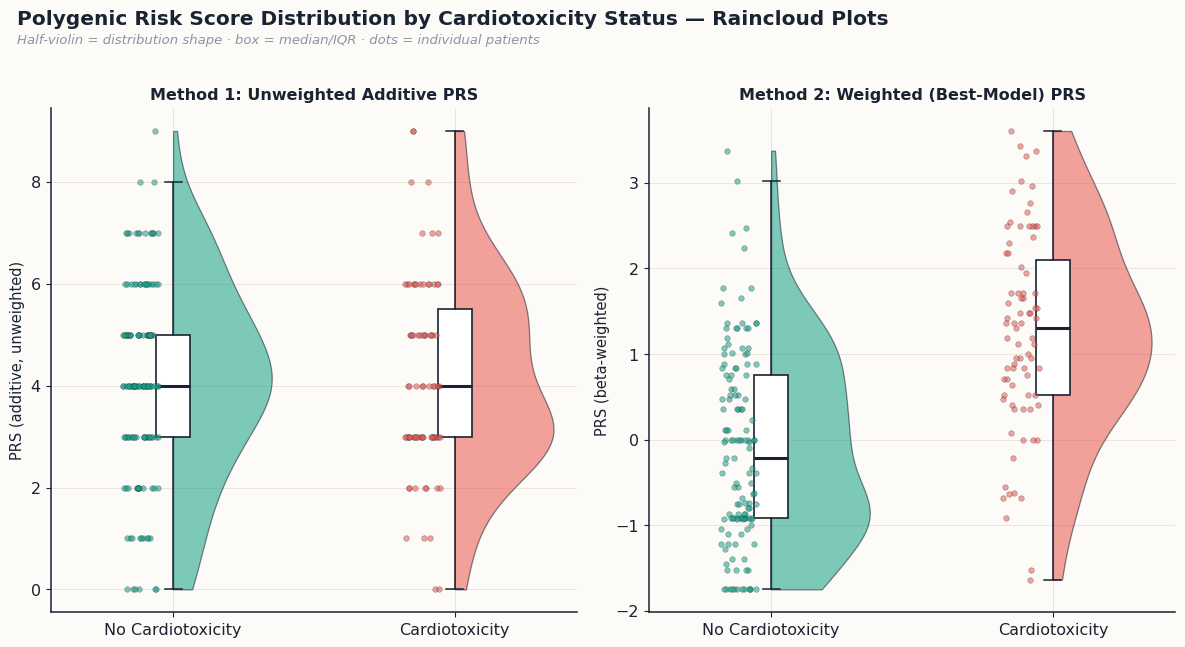

In [ ]:
def raincloud(ax, data_by_group, group_labels, group_colors, title, ylabel):
    """Logic: draws a half-violin (clipped to one side) + a slim boxplot + jittered raw points
    offset to the other side, for each group, on the same axis - the 'raincloud' layout."""
    positions = np.arange(len(data_by_group))

    # Half-violins
    parts = ax.violinplot(data_by_group, positions=positions, widths=0.7,
                           showmeans=False, showmedians=False, showextrema=False)
    for i, pc in enumerate(parts['bodies']):
        verts = pc.get_paths()[0].vertices
        verts[:, 0] = np.clip(verts[:, 0], positions[i], None)  # keep only the right half
        pc.set_facecolor(group_colors[i]); pc.set_edgecolor(INK)
        pc.set_linewidth(0.9); pc.set_alpha(0.55)

    # Slim boxplot (median + IQR) centered on each position
    ax.boxplot(data_by_group, positions=positions, widths=0.12, patch_artist=True,
               showfliers=False, manage_ticks=False,
               boxprops=dict(facecolor='white', edgecolor=INK, linewidth=1.2),
               medianprops=dict(color=INK, linewidth=2.2),
               whiskerprops=dict(color=INK, linewidth=1.1),
               capprops=dict(color=INK, linewidth=1.1))

    # Jittered raw points, offset to the left of each violin
    rng = np.random.default_rng(RANDOM_STATE)
    for i, vals in enumerate(data_by_group):
        jitter = rng.uniform(-0.18, -0.05, size=len(vals)) + positions[i]
        ax.scatter(jitter, vals, s=16, color=group_colors[i], alpha=0.55,
                   edgecolor=INK, linewidth=0.3, zorder=3)

    ax.set_xticks(positions); ax.set_xticklabels(group_labels, fontsize=11.5)
    ax.set_ylabel(ylabel, fontsize=10.5)
    ax.set_title(title, fontsize=11.5, fontweight='bold', color=INK)


fig, axes = plt.subplots(1, 2, figsize=(12, 6.2))
order = ['NO', 'YES']
group_colors = [TEAL, CORAL]
group_labels = ['No Cardiotoxicity', 'Cardiotoxicity']

raincloud(axes[0], [df.loc[df['Cardiotoxicity'] == g, 'PRS_additive'].values for g in order],
          group_labels, group_colors, 'Method 1: Unweighted Additive PRS', 'PRS (additive, unweighted)')
raincloud(axes[1], [df.loc[df['Cardiotoxicity'] == g, 'PRS_weighted'].values for g in order],
          group_labels, group_colors, 'Method 2: Weighted (Best-Model) PRS', 'PRS (beta-weighted)')

fig.suptitle('Polygenic Risk Score Distribution by Cardiotoxicity Status — Raincloud Plots',
             fontsize=14.5, fontweight='bold', color=INK, x=0.02, ha='left', y=1.04)
fig.text(0.02, 0.985, 'Half-violin = distribution shape · box = median/IQR · dots = individual patients',
         fontsize=9.5, color=GREY, style='italic', ha='left')
plt.tight_layout()
plt.show()


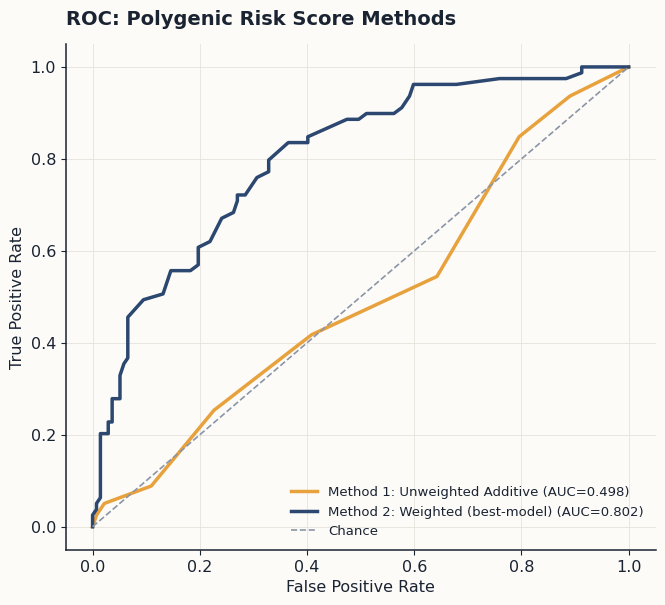

In [ ]:
# ---- ROC comparison: PRS Method 1 vs Method 2 ----
fig, ax = plt.subplots(figsize=(6.8, 6.2))
for col, name, color in [('PRS_additive', 'Method 1: Unweighted Additive', GOLD),
                          ('PRS_weighted', 'Method 2: Weighted (best-model)', NAVY)]:
    fpr, tpr, _ = roc_curve(y, df[col])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})', color=color, linewidth=2.5)
ax.plot([0, 1], [0, 1], linestyle='--', color=GREY, linewidth=1.2, label='Chance')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC: Polygenic Risk Score Methods', fontsize=14, fontweight='bold', loc='left', pad=14)
ax.legend(loc='lower right', frameon=False, fontsize=9.5)
plt.tight_layout()
plt.show()


---
### 3.1 PRS Tertile Analysis — Dose-Response Trend

Splitting patients into **PRS tertiles** (Low / Medium / High genetic risk, each ~⅓ of the cohort) is a standard way to check whether genetic risk behaves as a true **dose-response** relationship — i.e. does cardiotoxicity risk rise *monotonically* as PRS increases, not just differ between two arbitrary groups? This is more clinically actionable than a continuous score alone, since tertile group could map directly to a monitoring-intensity protocol (e.g. "High tertile -> more frequent cardiac screening").

In [ ]:
# Logic: pd.qcut splits PRS_weighted into 3 equal-sized groups by quantile (not equal-width bins),
# so each tertile has a comparable number of patients regardless of the score's distribution shape.
df['PRS_tertile'] = pd.qcut(df['PRS_weighted'], q=3, labels=['Low (T1)', 'Medium (T2)', 'High (T3)'])

print("Patients per tertile:")
print(df['PRS_tertile'].value_counts().sort_index())
print()

# Cardiotoxicity counts and rate (%) within each tertile
tab_n   = pd.crosstab(df['PRS_tertile'], df['Cardiotoxicity'])
tab_pct = pd.crosstab(df['PRS_tertile'], df['Cardiotoxicity'], normalize='index') * 100
print("Counts:")
display(tab_n)
print("Row percentages (cardiotoxicity rate within each tertile):")
display(tab_pct.round(1))

# Overall association test (3x2 Chi-square: tertile x outcome)
chi2, p, dof, exp = stats.chi2_contingency(tab_n)
print(f"\nChi-square (tertile vs outcome): chi2={chi2:.4f}, dof={dof}, p={p:.6f}")

# Logic: a dedicated TREND test (not just "any difference") - PRS_tertile is treated as an
# ORDINAL predictor (0,1,2) in a logistic regression. A significant positive coefficient here
# means risk increases monotonically across tertiles, which is a stronger and more specific
# claim than the omnibus Chi-square test above.
df['tertile_ord'] = df['PRS_tertile'].cat.codes
trend_model = smf.logit('Cardiotox_bin ~ tertile_ord', data=df).fit(disp=0)
print("\n=== Trend test: PRS tertile (ordinal) -> Cardiotoxicity ===")
print(trend_model.summary())
trend_or = np.exp(trend_model.params['tertile_ord'])
print(f"\nOdds ratio per tertile increase: {trend_or:.3f}  (p={trend_model.pvalues['tertile_ord']:.2e})")


Patients per tertile:
PRS_tertile
Low (T1)       73
Medium (T2)    71
High (T3)      72
Name: count, dtype: int64

Counts:


Cardiotoxicity,NO,YES
PRS_tertile,,
Low (T1),65,8
Medium (T2),45,26
High (T3),27,45


Row percentages (cardiotoxicity rate within each tertile):


Cardiotoxicity,NO,YES
PRS_tertile,,
Low (T1),89.0,11.0
Medium (T2),63.4,36.6
High (T3),37.5,62.5



Chi-square (tertile vs outcome): chi2=41.5103, dof=2, p=0.000000

=== Trend test: PRS tertile (ordinal) -> Cardiotoxicity ===
                           Logit Regression Results                           
Dep. Variable:          Cardiotox_bin   No. Observations:                  216
Model:                          Logit   Df Residuals:                      214
Method:                           MLE   Df Model:                            1
Date:                Sat, 27 Jun 2026   Pseudo R-squ.:                  0.1555
Time:                        11:29:00   Log-Likelihood:                -119.77
converged:                       True   LL-Null:                       -141.84
Covariance Type:            nonrobust   LLR p-value:                 3.083e-11
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -1.9482      0.299     -6.509      0.000      -2.535      -1.362
t

**Dose-response chart** — a line connecting the cardiotoxicity rate (%) at each tertile is the clearest way to show a monotonic trend; a bar chart of the same numbers would obscure the *trend* in favor of just three isolated heights.

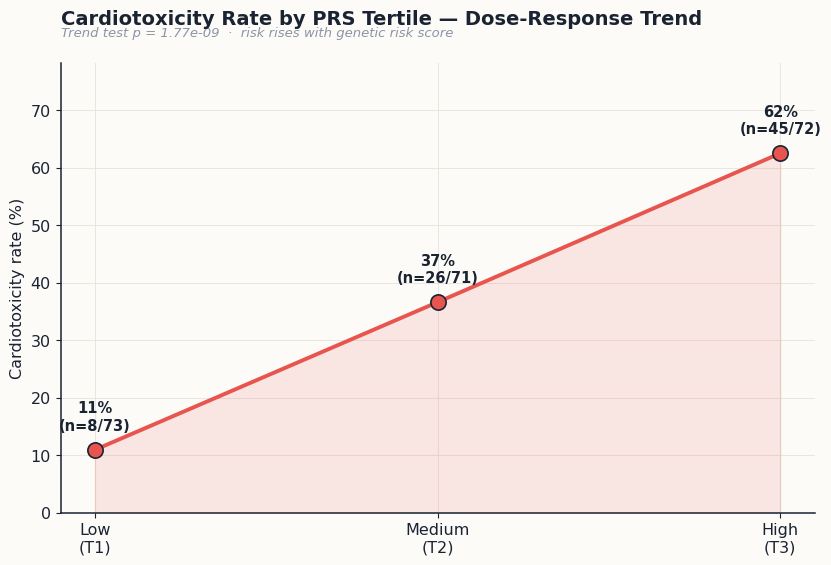

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 5.8))
x = np.arange(3)
yes_pct = tab_pct['YES'].values

ax.plot(x, yes_pct, color=CORAL, linewidth=2.8, marker='o', markersize=11,
        markerfacecolor=CORAL, markeredgecolor=INK, markeredgewidth=1.2, zorder=3)
ax.fill_between(x, 0, yes_pct, color=CORAL, alpha=0.12)

for i, tert in enumerate(tab_pct.index):
    n_yes = tab_n.loc[tert, 'YES']; n_tot = tab_n.loc[tert].sum()
    ax.annotate(f'{yes_pct[i]:.0f}%\n(n={n_yes}/{n_tot})', (i, yes_pct[i]), textcoords='offset points',
                xytext=(0, 14), ha='center', fontsize=10.5, fontweight='bold', color=INK)

ax.set_xticks(x); ax.set_xticklabels(['Low\n(T1)', 'Medium\n(T2)', 'High\n(T3)'], fontsize=11.5)
ax.set_ylabel('Cardiotoxicity rate (%)', fontsize=11.5)
ax.set_ylim(0, max(yes_pct) * 1.25)
ax.set_title('Cardiotoxicity Rate by PRS Tertile — Dose-Response Trend', fontsize=14, fontweight='bold', loc='left', pad=28)
ax.text(0, 1.06, f'Trend test p = {trend_model.pvalues["tertile_ord"]:.2e}  ·  risk rises with genetic risk score',
        transform=ax.transAxes, fontsize=9.5, color=GREY, style='italic')
plt.tight_layout()
plt.show()


**Interpretation:** if the cardiotoxicity rate rises clearly and consistently from the Low to High tertile (check the printed percentages and the trend-test p-value above), this is strong evidence that the weighted PRS captures a genuine, clinically usable risk gradient — not just statistical noise from a single cutoff.

---
### 3.2 How Risk Alleles Were Defined for PRS

A critical but often under-reported step in any PRS is: **which allele is the "risk" allele for each SNP, and why?** This matters because getting the direction wrong for even one SNP degrades the whole score — and is exactly why Method 1 (unweighted additive) performed so poorly (AUC 0.43).

For **Method 2 (weighted PRS)**, each SNP's contribution is determined by the **sign of the logistic regression beta coefficient** when the minor allele count (0/1/2) is the predictor:
- **Positive beta** → more minor alleles = higher cardiotoxicity risk → minor allele is the **risk allele**
- **Negative beta** → more minor alleles = *lower* cardiotoxicity risk → minor allele is actually **protective**, meaning the major allele is the risk allele

This is also why Method 1 fails: it simply adds up minor allele counts without considering that some SNPs' minor alleles protect against cardiotoxicity — so adding them in naively *cancels out* the real signal.

In [ ]:
# Logic: for each SNP, fit the simple additive logistic regression (same as Section 2)
# and read off the beta coefficient to determine directionality of the minor allele's effect.
# This table is the methodological justification for how PRS Method 2 handles each SNP.

risk_allele_rows = []
for snp in SNPS:
    info = model_coding_store[snp]
    tmp = pd.DataFrame({'y': df['Cardiotox_bin'], 'x': info['coded']['additive']})
    m = smf.logit('y ~ x', data=tmp).fit(disp=0)
    beta = m.params['x']
    or_val = np.exp(beta)
    minor, major = info['minor'], info['major']

    # Logic: if beta > 0, adding more copies of the minor allele increases log-odds of cardiotoxicity
    # -> minor allele is the risk allele. If beta < 0, it is protective -> major allele is the risk allele.
    risk_allele = minor if beta > 0 else major
    direction = 'Risk-increasing' if beta > 0 else 'Protective'

    # Contribution in PRS Method 2: the beta coefficient IS the weight, so its sign is critical.
    risk_allele_rows.append({
        'SNP': snp,
        'Minor_allele': minor,
        'Major_allele': major,
        'Minor_allele_freq': round(allele_df.set_index('SNP').loc[snp, 'Freq_minor'], 3)
                if 'Freq_minor' in allele_df.columns
                else round(min(allele_df.set_index('SNP').loc[snp, 'Freq_Allele1_overall'],
                               allele_df.set_index('SNP').loc[snp, 'Freq_Allele2_overall']), 3),
        'Beta_additive_model': round(beta, 4),
        'OR_per_minor_allele': round(or_val, 4),
        'Minor_allele_effect': direction,
        'Risk_allele': risk_allele,
        'PRS_Method2_note': (f"Minor ({minor}) count increases PRS (risk)" if beta > 0
                             else f"Minor ({minor}) count decreases PRS (protective)")
    })

risk_allele_df = pd.DataFrame(risk_allele_rows)
print("=== Risk Allele Definition for PRS ===")
display(risk_allele_df)

print("""
Key interpretation:
- For SOD2, PNPLA3, ABCC1, CBR1: the minor (variant) allele is risk-increasing
  -> adding its count correctly raises PRS.
  Note: CBR1 minor allele = A (variant); GG is the reference genotype.
  After correcting CBR1 genotype orientation (GG=ref, GA=het, AA=variant),
  the A allele increases cardiotoxicity risk (OR > 1, positive beta).
- For ABCG2: the minor allele is PROTECTIVE (OR < 1) -> the major allele is the risk allele.
  This is why Method 1 performed poorly for ABCG2: it was subtracting risk signal instead of adding it.
""")


=== Risk Allele Definition for PRS ===


,SNP,Minor_allele,Major_allele,Minor_allele_freq,Beta_additive_model,OR_per_minor_allele,Minor_allele_effect,Risk_allele,PRS_Method2_note
0,SOD2,G,T,0.312,0.2563,1.2921,Risk-increasing,G,Minor (G) count increases PRS (risk)
1,PNPLA3,G,C,0.398,0.1778,1.1946,Risk-increasing,G,Minor (G) count increases PRS (risk)
2,ABCC1,T,G,0.312,0.1152,1.1220,Risk-increasing,T,Minor (T) count increases PRS (risk)
3,CBR1,A,G,0.419,0.3809,1.4636,Risk-increasing,A,Minor (A) count increases PRS (risk)
4,ABCG2,A,C,0.440,-0.7049,0.4942,Protective,C,Minor (A) count decreases PRS (protective)



Key interpretation:
- For SOD2, PNPLA3, ABCC1, CBR1: the minor (variant) allele is risk-increasing
  -> adding its count correctly raises PRS.
  Note: CBR1 minor allele = A (variant); GG is the reference genotype.
  After correcting CBR1 genotype orientation (GG=ref, GA=het, AA=variant),
  the A allele increases cardiotoxicity risk (OR > 1, positive beta).
- For ABCG2: the minor allele is PROTECTIVE (OR < 1) -> the major allele is the risk allele.
  This is why Method 1 performed poorly for ABCG2: it was subtracting risk signal instead of adding it.



---
## 4. Logistic Regression Models — Demographic, Genetic, and Fully Adjusted

We fit **three logistic regression models** progressively:
1. **Demographic-only** — Gender, Age, ALL subtype, Cancer history (isolates non-genetic predictors)
2. **Genetic-only** — All 5 SNPs in additive coding (isolates genetic predictors)
3. **Multivariate (fully adjusted)** — All SNPs + all demographics together: this is the **confounder-adjusted model** where each SNP's OR is "holding demographics constant" and each demographic variable's OR is "holding genotype constant." The LRT (likelihood ratio test) also tells us whether adding genetics to demographics significantly improves model fit.

In [ ]:
# ---- Model 1: Demographic-only ----
demo_formula = 'Cardiotox_bin ~ GENDER_bin + AGE + ALL_TYPE_bin + HISTORY_bin'
demo_model = smf.logit(demo_formula, data=df).fit(disp=0)
print(demo_model.summary())


                           Logit Regression Results                           
Dep. Variable:          Cardiotox_bin   No. Observations:                  216
Model:                          Logit   Df Residuals:                      211
Method:                           MLE   Df Model:                            4
Date:                Sat, 27 Jun 2026   Pseudo R-squ.:                 0.01973
Time:                        11:29:00   Log-Likelihood:                -139.04
converged:                       True   LL-Null:                       -141.84
Covariance Type:            nonrobust   LLR p-value:                    0.2313
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.3932      0.383     -1.026      0.305      -1.144       0.358
GENDER_bin      -0.1739      0.318     -0.547      0.584      -0.797       0.449
AGE             -0.0281      0.038     -0.73

In [ ]:
params = demo_model.params
conf = demo_model.conf_int(); conf.columns = ['2.5%', '97.5%']
or_table = pd.DataFrame({
    'Coef': params, 'OR': np.exp(params),
    'OR_2.5%': np.exp(conf['2.5%']), 'OR_97.5%': np.exp(conf['97.5%']),
    'p_value': demo_model.pvalues
}).round(4)
print("=== Odds Ratios - Demographic Model ===")
display(or_table)


=== Odds Ratios - Demographic Model ===


,Coef,OR,OR_2.5%,OR_97.5%,p_value
Intercept,-0.3932,0.6749,0.3185,1.4300,0.3047
GENDER_bin,-0.1739,0.8403,0.4508,1.5664,0.5840
AGE,-0.0281,0.9722,0.9019,1.0481,0.4625
ALL_TYPE_bin,-0.0096,0.9904,0.4842,2.0261,0.9790
HISTORY_bin,0.7155,2.0453,1.0647,3.9289,0.0317


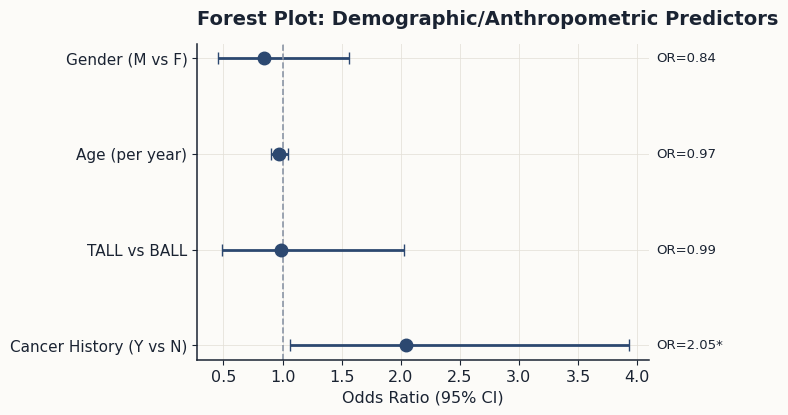

In [ ]:
labels_map = {'GENDER_bin': 'Gender (M vs F)', 'AGE': 'Age (per year)',
              'ALL_TYPE_bin': 'TALL vs BALL', 'HISTORY_bin': 'Cancer History (Y vs N)'}
p_demo = demo_model.params.drop('Intercept')
c_demo = demo_model.conf_int().drop('Intercept')
pv_demo = demo_model.pvalues.drop('Intercept')

fig, ax = plt.subplots(figsize=(7.5, 4.3))
yvals = np.arange(len(p_demo))[::-1]
ors, lo, hi = np.exp(p_demo.values), np.exp(c_demo[0].values), np.exp(c_demo[1].values)
ax.errorbar(ors, yvals, xerr=[ors - lo, hi - ors], fmt='o', color=NAVY, ecolor=NAVY,
            elinewidth=2, capsize=4, markersize=9)
ax.axvline(1, color=GREY, linestyle='--', linewidth=1.2)
ax.set_yticks(yvals); ax.set_yticklabels([labels_map[i] for i in p_demo.index], fontsize=11)
ax.set_xlabel('Odds Ratio (95% CI)')
ax.set_title('Forest Plot: Demographic/Anthropometric Predictors', fontsize=14, fontweight='bold', loc='left', pad=14)
for yv, orv, p in zip(yvals, ors, pv_demo.values):
    sig = '*' if p < 0.05 else ''
    ax.text(hi.max() * 1.06, yv, f'OR={orv:.2f}{sig}', va='center', fontsize=9.5, color=INK)
plt.tight_layout()
plt.show()


In [ ]:
# ---- Model 2: Genetic-only ----
for snp in SNPS:
    df[f'{snp}_add'] = model_coding_store[snp]['coded']['additive']

gen_formula = 'Cardiotox_bin ~ SOD2_add + PNPLA3_add + ABCC1_add + CBR1_add + ABCG2_add'
gen_model = smf.logit(gen_formula, data=df).fit(disp=0)
print(gen_model.summary())

params_g = gen_model.params; conf_g = gen_model.conf_int(); conf_g.columns = ['2.5%', '97.5%']
or_table_g = pd.DataFrame({
    'Coef': params_g, 'OR': np.exp(params_g),
    'OR_2.5%': np.exp(conf_g['2.5%']), 'OR_97.5%': np.exp(conf_g['97.5%']),
    'p_value': gen_model.pvalues
}).round(4)
print("\n=== Odds Ratios - Genetic-only Model ===")
display(or_table_g)
print(f"\nDemographic model Pseudo R-sq: {demo_model.prsquared:.4f}  |  Genetic-only Pseudo R-sq: {gen_model.prsquared:.4f}")


                           Logit Regression Results                           
Dep. Variable:          Cardiotox_bin   No. Observations:                  216
Model:                          Logit   Df Residuals:                      210
Method:                           MLE   Df Model:                            5
Date:                Sat, 27 Jun 2026   Pseudo R-squ.:                  0.1078
Time:                        11:29:00   Log-Likelihood:                -126.54
converged:                       True   LL-Null:                       -141.84
Covariance Type:            nonrobust   LLR p-value:                 1.130e-05
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9149      0.368     -2.488      0.013      -1.636      -0.194
SOD2_add       0.3313      0.201      1.648      0.099      -0.063       0.725
PNPLA3_add     0.1216      0.173      0.704      0.4

,Coef,OR,OR_2.5%,OR_97.5%,p_value
Intercept,-0.9149,0.4005,0.1948,0.8235,0.0128
SOD2_add,0.3313,1.3927,0.9391,2.0654,0.0994
PNPLA3_add,0.1216,1.1293,0.8049,1.5846,0.4815
ABCC1_add,0.0655,1.0676,0.7297,1.5620,0.7360
CBR1_add,0.5107,1.6664,1.1710,2.3716,0.0046
ABCG2_add,-0.7629,0.4663,0.3303,0.6583,0.0000



Demographic model Pseudo R-sq: 0.0197  |  Genetic-only Pseudo R-sq: 0.1078


---
### 4.1 Multivariate Logistic Regression — Adjusted for Confounders

Including all SNPs AND demographic variables in the same model allows us to ask: **does each SNP's association with cardiotoxicity persist even after accounting for age, gender, ALL subtype, and cancer history?** This is the standard way to control for potential confounders in a clinical genetics study.

The **Likelihood Ratio Test (LRT)** at the bottom compares the full model to the demographics-only model — a significant result means the 5 SNPs together contribute statistically meaningful predictive information beyond what demographics alone can provide.

In [ ]:
# Logic: the fully-adjusted model puts SNPs and demographics in the same regression simultaneously.
# Each coefficient is then a PARTIAL effect - e.g. CBR1's OR is "after adjusting for age, gender,
# cancer history, ALL subtype, and the other 4 SNPs". This is much stronger evidence of an
# independent genetic effect than the univariate allele/genotype chi-square tests in Sections 1-2.

full_formula = ('Cardiotox_bin ~ SOD2_add + PNPLA3_add + ABCC1_add + CBR1_add + ABCG2_add'
                ' + GENDER_bin + AGE + ALL_TYPE_bin + HISTORY_bin')
full_model = smf.logit(full_formula, data=df).fit(disp=0)
print(full_model.summary())

params_f = full_model.params; conf_f = full_model.conf_int(); conf_f.columns = ['2.5%', '97.5%']
or_table_f = pd.DataFrame({
    'Coef': params_f, 'OR': np.exp(params_f),
    'OR_2.5%': np.exp(conf_f['2.5%']), 'OR_97.5%': np.exp(conf_f['97.5%']),
    'p_value': full_model.pvalues
}).round(4)
print("\n=== Odds Ratios - Fully Adjusted Multivariate Model ===")
display(or_table_f)


                           Logit Regression Results                           
Dep. Variable:          Cardiotox_bin   No. Observations:                  216
Model:                          Logit   Df Residuals:                      206
Method:                           MLE   Df Model:                            9
Date:                Sat, 27 Jun 2026   Pseudo R-squ.:                  0.1323
Time:                        11:29:00   Log-Likelihood:                -123.07
converged:                       True   LL-Null:                       -141.84
Covariance Type:            nonrobust   LLR p-value:                 2.110e-05
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.5522      0.547     -1.009      0.313      -1.625       0.520
SOD2_add         0.3694      0.205      1.799      0.072      -0.033       0.772
PNPLA3_add       0.1632      0.177      0.92

,Coef,OR,OR_2.5%,OR_97.5%,p_value
Intercept,-0.5522,0.5757,0.1970,1.6823,0.3128
SOD2_add,0.3694,1.4469,0.9676,2.1636,0.0720
PNPLA3_add,0.1632,1.1772,0.8316,1.6666,0.3576
ABCC1_add,0.0099,1.0100,0.6806,1.4987,0.9606
CBR1_add,0.5322,1.7027,1.1885,2.4394,0.0037
ABCG2_add,-0.7976,0.4504,0.3142,0.6455,0.0000
GENDER_bin,-0.3651,0.6942,0.3524,1.3672,0.2912
AGE,-0.0447,0.9563,0.8802,1.0390,0.2908
ALL_TYPE_bin,-0.0146,0.9855,0.4545,2.1367,0.9704
HISTORY_bin,0.7795,2.1803,1.0690,4.4469,0.0321


In [ ]:
# ---- Likelihood Ratio Test: does adding genetics improve the demographic-only model? ----
from scipy.stats import chi2 as chi2_dist
lrt_stat = -2 * (demo_model.llf - full_model.llf)
lrt_p    = chi2_dist.sf(lrt_stat, df=5)   # df = number of extra parameters (5 SNPs)

print(f"Likelihood Ratio Test — Genetics adds over Demographics alone:")
print(f"  LRT statistic: {lrt_stat:.4f}")
print(f"  Degrees of freedom: 5 (one per SNP added)")
print(f"  p-value: {lrt_p:.6f}")
print()
print(f"AIC comparison:")
print(f"  Demographics-only AIC : {demo_model.aic:.2f}")
print(f"  Fully-adjusted AIC    : {full_model.aic:.2f}  (lower = better fit)")
print(f"  AIC improvement       : {demo_model.aic - full_model.aic:.2f}")
print(f"\nPseudo R-squared:")
print(f"  Demographics-only  : {demo_model.prsquared:.4f}")
print(f"  Genetics-only      : {gen_model.prsquared:.4f}")
print(f"  Fully-adjusted     : {full_model.prsquared:.4f}")


Likelihood Ratio Test — Genetics adds over Demographics alone:
  LRT statistic: 31.9392
  Degrees of freedom: 5 (one per SNP added)
  p-value: 0.000006

AIC comparison:
  Demographics-only AIC : 288.08
  Fully-adjusted AIC    : 266.14  (lower = better fit)
  AIC improvement       : 21.94

Pseudo R-squared:
  Demographics-only  : 0.0197
  Genetics-only      : 0.1078
  Fully-adjusted     : 0.1323


**Combined forest plot** comparing SNP odds ratios in the genetic-only model vs the fully-adjusted model — if an OR stays similar after adjustment, that SNP's effect is not confounded by demographics. If it changes substantially, a demographic variable was confounding the association.

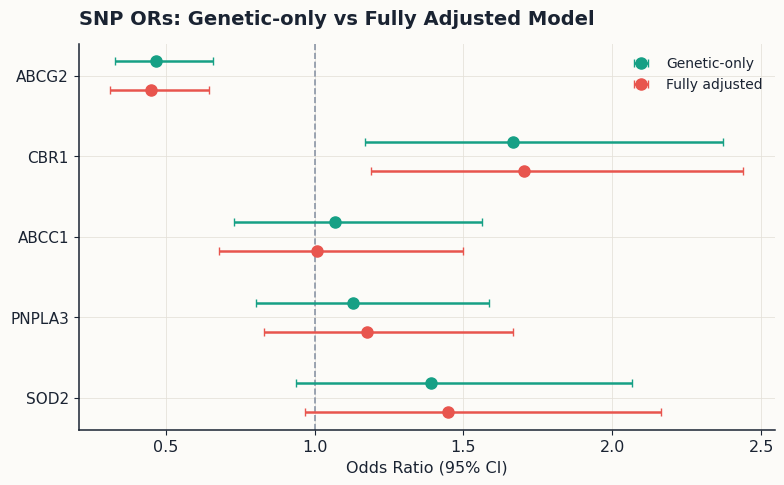

In [ ]:
# Logic: display genetic ORs from both models side-by-side so any confounding effect of demographics
# is immediately visible as a difference between the two sets of error bars.
snp_vars = [s+'_add' for s in SNPS]
snp_labels = SNPS

fig, ax = plt.subplots(figsize=(8, 5))
yvals = np.arange(len(snp_vars))
offset = 0.18

for i, (model, label, color, off) in enumerate([
    (gen_model,  'Genetic-only',     TEAL, +offset),
    (full_model, 'Fully adjusted',   CORAL, -offset)
]):
    ors_m = np.exp(model.params[snp_vars].values)
    ci_m  = model.conf_int().loc[snp_vars]
    lo_m  = np.exp(ci_m[0].values); hi_m = np.exp(ci_m[1].values)
    ax.errorbar(ors_m, yvals + off, xerr=[ors_m - lo_m, hi_m - ors_m],
                fmt='o', color=color, ecolor=color, elinewidth=1.8, capsize=3, markersize=8,
                label=label, zorder=3)

ax.axvline(1, color=GREY, linestyle='--', linewidth=1.2)
ax.set_yticks(yvals); ax.set_yticklabels(snp_labels, fontsize=11)
ax.set_xlabel('Odds Ratio (95% CI)')
ax.set_title('SNP ORs: Genetic-only vs Fully Adjusted Model', fontsize=14, fontweight='bold', loc='left', pad=14)
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()


---
## 5. Machine Learning Models

We train **5 classifiers** (Logistic Regression, SVM, Decision Tree, XGBoost, LightGBM) on the combined demographic + SNP feature set, using an **80:20 stratified split**. For each model we run two versions:
- **Without SMOTE** — trained on the raw class-imbalanced training set (109 NO : 63 YES)
- **With SMOTE** — training set synthetically balanced to 109:109 using Synthetic Minority Over-sampling, then the same held-out test set is used for evaluation

SMOTE generates synthetic minority-class (YES) samples by interpolating between existing ones in feature space — it is applied **only to the training set**, never to the test set, so evaluation remains on real patients.

Features: `GENDER_bin, AGE, ALL_TYPE_bin, HISTORY_bin, SOD2_add, PNPLA3_add, ABCC1_add, CBR1_add, ABCG2_add`

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgb
from imblearn.over_sampling import SMOTE

feature_cols = ['GENDER_bin', 'AGE', 'ALL_TYPE_bin', 'HISTORY_bin',
                 'SOD2_add', 'PNPLA3_add', 'ABCC1_add', 'CBR1_add', 'ABCG2_add']
# Human-readable labels for SHAP plots (same order as feature_cols)
feature_labels = ['Gender', 'Age', 'ALL Subtype', 'Cancer History',
                   'SOD2', 'PNPLA3', 'ABCC1', 'CBR1', 'ABCG2']

X = df[feature_cols].copy()
y = df['Cardiotox_bin'].copy()

# Stratified 80:20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Train size:", X_train.shape, " | Test size:", X_test.shape)
print("Train class balance:", y_train.value_counts().to_dict())
print("Test class balance:",  y_test.value_counts().to_dict())

# MinMaxScaler fitted on train only, applied to both train and test
scaler = MinMaxScaler()
X_tr_s  = scaler.fit_transform(X_train)
X_te_s  = scaler.transform(X_test)
X_tr_df = pd.DataFrame(X_tr_s,  columns=feature_labels)
X_te_df = pd.DataFrame(X_te_s,  columns=feature_labels)
X_tr_raw_df = pd.DataFrame(X_train.values, columns=feature_labels)  # unscaled, for tree SHAP
X_te_raw_df = pd.DataFrame(X_test.values,  columns=feature_labels)

# Logic: SMOTE on the scaled training set only (not the test set - we never touch the test set).
# We also build a separate SMOTE-on-raw version for tree-based models (XGB, LGBM, DT)
# which don't need scaling but still benefit from SMOTE oversampling.
smote = SMOTE(random_state=RANDOM_STATE)
X_tr_sm_s,   y_tr_sm   = smote.fit_resample(X_tr_s,   y_train)   # scaled   -> LR, SVM
X_tr_sm_raw, y_tr_sm_r = smote.fit_resample(X_train,  y_train)   # unscaled -> DT, XGB, LGBM
print(f"\nAfter SMOTE (training set): {pd.Series(y_tr_sm).value_counts().to_dict()}")


Train size: (172, 9)  | Test size: (44, 9)
Train class balance: {0: 109, 1: 63}
Test class balance: {0: 28, 1: 16}

After SMOTE (training set): {1: 109, 0: 109}


### 5.1 Train All 5 Models (Without and With SMOTE)

In [ ]:
def get_metrics(name, y_true, y_pred, y_prob):
    """Compute the standard 5-metric classification summary."""
    return {
        'Model': name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'AUC':       round(roc_auc_score(y_true, y_prob), 4)
    }

# Store fitted models for SHAP later
fitted_base  = {}   # no SMOTE
fitted_smote = {}   # with SMOTE
rows_base, rows_smote = [], []

# --- Helper to train and evaluate one configuration ---
def train_eval(name, model_fn, Xtr, ytr, Xte, ytest, store_dict, rows_list):
    m = model_fn().fit(Xtr, ytr)
    store_dict[name] = m
    rows_list.append(get_metrics(name, ytest, m.predict(Xte), m.predict_proba(Xte)[:, 1]))
    return m

# -- WITHOUT SMOTE --
train_eval('LogisticRegression',
    lambda: LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_tr_s, y_train, X_te_s, y_test, fitted_base, rows_base)

train_eval('SVM',
    lambda: SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    X_tr_s, y_train, X_te_s, y_test, fitted_base, rows_base)

train_eval('DecisionTree',
    lambda: DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    X_tr_s, y_train, X_te_s, y_test, fitted_base, rows_base)

train_eval('XGBoost',
    lambda: xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,
                                eval_metric='logloss', random_state=RANDOM_STATE),
    X_train, y_train, X_test, y_test, fitted_base, rows_base)

train_eval('LightGBM',
    lambda: lgb.LGBMClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,
                                random_state=RANDOM_STATE, verbose=-1),
    X_train, y_train, X_test, y_test, fitted_base, rows_base)

# -- WITH SMOTE --
train_eval('LogisticRegression',
    lambda: LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_tr_sm_s, y_tr_sm, X_te_s, y_test, fitted_smote, rows_smote)

train_eval('SVM',
    lambda: SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    X_tr_sm_s, y_tr_sm, X_te_s, y_test, fitted_smote, rows_smote)

train_eval('DecisionTree',
    lambda: DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    X_tr_sm_s, y_tr_sm, X_te_s, y_test, fitted_smote, rows_smote)

train_eval('XGBoost',
    lambda: xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,
                                eval_metric='logloss', random_state=RANDOM_STATE),
    X_tr_sm_raw, y_tr_sm_r, X_test, y_test, fitted_smote, rows_smote)

train_eval('LightGBM',
    lambda: lgb.LGBMClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,
                                random_state=RANDOM_STATE, verbose=-1),
    X_tr_sm_raw, y_tr_sm_r, X_test, y_test, fitted_smote, rows_smote)

metrics_base  = pd.DataFrame(rows_base).set_index('Model').round(4)
metrics_smote = pd.DataFrame(rows_smote).set_index('Model').round(4)

print("=== WITHOUT SMOTE ===")
display(metrics_base)
print("\n=== WITH SMOTE ===")
display(metrics_smote)
print("\n=== F1 change (SMOTE - no SMOTE) ===")
display((metrics_smote['F1'] - metrics_base['F1']).round(4).to_frame('ΔF1'))


=== WITHOUT SMOTE ===


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
LogisticRegression,0.5909,0.4444,0.500,0.4706,0.6696
SVM,0.6591,0.5333,0.500,0.5161,0.6507
DecisionTree,0.7273,0.6250,0.625,0.6250,0.7176
XGBoost,0.5909,0.4545,0.625,0.5263,0.7121
LightGBM,0.6818,0.5556,0.625,0.5882,0.7299



=== WITH SMOTE ===


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
LogisticRegression,0.5909,0.4643,0.8125,0.5909,0.7031
SVM,0.6364,0.5000,0.5625,0.5294,0.6585
DecisionTree,0.7273,0.6250,0.6250,0.6250,0.7344
XGBoost,0.5909,0.4583,0.6875,0.5500,0.7098
LightGBM,0.6136,0.4783,0.6875,0.5641,0.6920



=== F1 change (SMOTE - no SMOTE) ===


,ΔF1
Model,
LogisticRegression,0.1203
SVM,0.0133
DecisionTree,0.0000
XGBoost,0.0237
LightGBM,-0.0241


### 5.2 Hyperparameter Tuning with 5-Fold Cross-Validation

GridSearchCV searches a predefined grid of hyperparameter combinations, evaluating each via 5-fold stratified CV on the training set (never touching the test set). The best combination is then refit on the full training set and evaluated on the held-out test.

> **Tip:** If a tuned model's Recall or F1 collapses toward 0 despite a decent AUC, it means the CV-optimised AUC is tolerating a high false-negative rate. Switch `scoring='roc_auc'` to `scoring='balanced_accuracy'` in that model's GridSearchCV call to penalise this behaviour.

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# -- Logistic Regression: tune regularisation strength C --
gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    {'C': [0.01, 0.1, 1, 10, 100]},
    cv=cv, scoring='roc_auc', n_jobs=-1
).fit(X_tr_s, y_train)

# -- SVM: tune margin penalty C and kernel width gamma --
gs_svm = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]},
    cv=cv, scoring='roc_auc', n_jobs=-1
).fit(X_tr_s, y_train)

# -- Decision Tree: tune depth and minimum samples for a split --
gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {'max_depth': [2, 3, 4, 5, 6], 'min_samples_split': [2, 5, 10]},
    cv=cv, scoring='roc_auc', n_jobs=-1
).fit(X_tr_s, y_train)

# -- XGBoost: tune depth, learning rate, tree count, and subsampling --
gs_xgb = GridSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE),
    {'n_estimators': [100, 200, 300], 'max_depth': [2, 3, 4],
     'learning_rate': [0.05, 0.1, 0.2], 'subsample': [0.8, 1.0]},
    cv=cv, scoring='roc_auc', n_jobs=-1
).fit(X_train, y_train)

# -- LightGBM: tune depth, learning rate, and number of leaves --
gs_lgb = GridSearchCV(
    lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    {'n_estimators': [100, 200], 'max_depth': [2, 3, 4],
     'learning_rate': [0.05, 0.1, 0.2], 'num_leaves': [15, 31, 63]},
    cv=cv, scoring='roc_auc', n_jobs=-1
).fit(X_train, y_train)

print("Grid search complete.")

tuned_rows = []
gs_map = {'LogisticRegression': (gs_lr, X_te_s), 'SVM': (gs_svm, X_te_s),
           'DecisionTree': (gs_dt, X_te_s), 'XGBoost': (gs_xgb, X_test), 'LightGBM': (gs_lgb, X_test)}
for name, (gs, Xte) in gs_map.items():
    pred = gs.predict(Xte); prob = gs.predict_proba(Xte)[:, 1]
    row = get_metrics(name, y_test, pred, prob)
    row['CV_AUC'] = round(gs.best_score_, 4)
    row['Best_Params'] = str(gs.best_params_)
    tuned_rows.append(row)
tuned_df = pd.DataFrame(tuned_rows).set_index('Model')
print("\n=== Tuned Model Performance (Test Set) ===")
display(tuned_df)
print("\nComparison (Tuned AUC - Baseline AUC):")
display((tuned_df['AUC'] - metrics_base['AUC']).round(4).to_frame('ΔAUC'))


Grid search complete.

=== Tuned Model Performance (Test Set) ===


,Accuracy,Precision,Recall,F1,AUC,CV_AUC,Best_Params
Model,,,,,,,
LogisticRegression,0.5909,0.4444,0.5000,0.4706,0.6696,0.6820,{'C': 1}
SVM,0.6364,0.0000,0.0000,0.0000,0.6562,0.6875,"{'C': 0.1, 'gamma': 0.001}"
DecisionTree,0.7045,0.7143,0.3125,0.4348,0.6953,0.7220,"{'max_depth': 2, 'min_samples_split': 2}"
XGBoost,0.7045,0.5882,0.6250,0.6061,0.7321,0.7951,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est..."
LightGBM,0.6591,0.5238,0.6875,0.5946,0.7210,0.7823,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."



Comparison (Tuned AUC - Baseline AUC):


,ΔAUC
Model,
LogisticRegression,0.0000
SVM,0.0055
DecisionTree,-0.0223
XGBoost,0.0200
LightGBM,-0.0089


### 5.2.1 Tuned Model Evaluation — Charts (20% Test Set, No SMOTE)

The three charts below apply the same evaluation framework used for baseline models (Section 5.3) to the tuned models, so results are directly comparable. The key question is whether GridSearchCV-selected hyperparameters improve performance over the defaults on the held-out 20% test set.

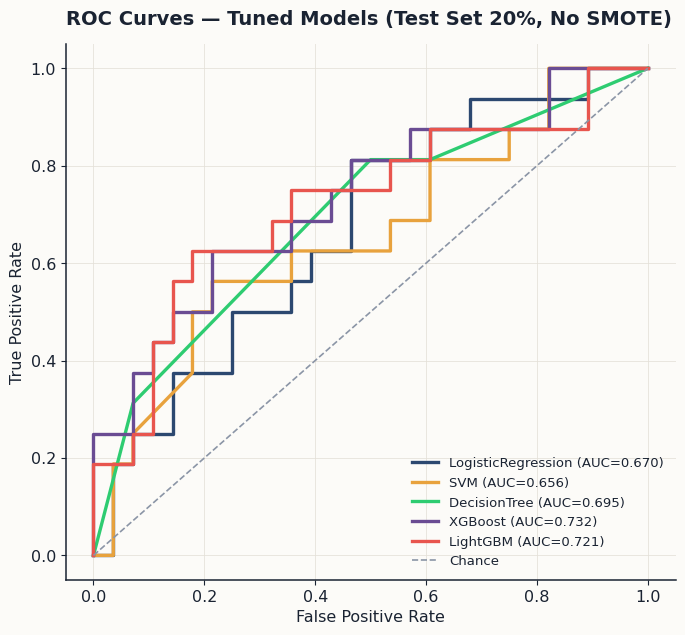

In [ ]:
MODEL_COLORS_5 = {
    'LogisticRegression': NAVY, 'SVM': GOLD, 'DecisionTree': '#2ECC71',
    'XGBoost': '#6A4C93', 'LightGBM': CORAL
}

# Logic: collect predictions and probabilities from every tuned model,
# then plot the same three chart types used for baseline models (ROC, confusion matrix, radar)
# so the reader can directly compare tuned vs baseline performance visually.

tuned_preds_eval = {}
tuned_probs_eval = {}

# Re-extract from the gs_map fitted objects above
gs_eval_map = {
    'LogisticRegression': (gs_lr,  X_te_s),
    'SVM':                (gs_svm, X_te_s),
    'DecisionTree':       (gs_dt,  X_te_s),
    'XGBoost':            (gs_xgb, X_test),
    'LightGBM':           (gs_lgb, X_test),
}
for name, (gs, Xte) in gs_eval_map.items():
    tuned_preds_eval[name] = gs.predict(Xte)
    tuned_probs_eval[name] = gs.predict_proba(Xte)[:, 1]

# ---- Combined ROC curves — tuned models ----
fig, ax = plt.subplots(figsize=(7, 6.5))
for name, color in MODEL_COLORS_5.items():
    fpr, tpr, _ = roc_curve(y_test, tuned_probs_eval[name])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2.4,
            label=f'{name} (AUC={roc_auc_val:.3f})')
ax.plot([0, 1], [0, 1], '--', color=GREY, linewidth=1.2, label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Tuned Models (Test Set 20%, No SMOTE)',
             fontsize=14, fontweight='bold', loc='left', pad=14)
ax.legend(loc='lower right', frameon=False, fontsize=9.5)
plt.tight_layout()
plt.show()


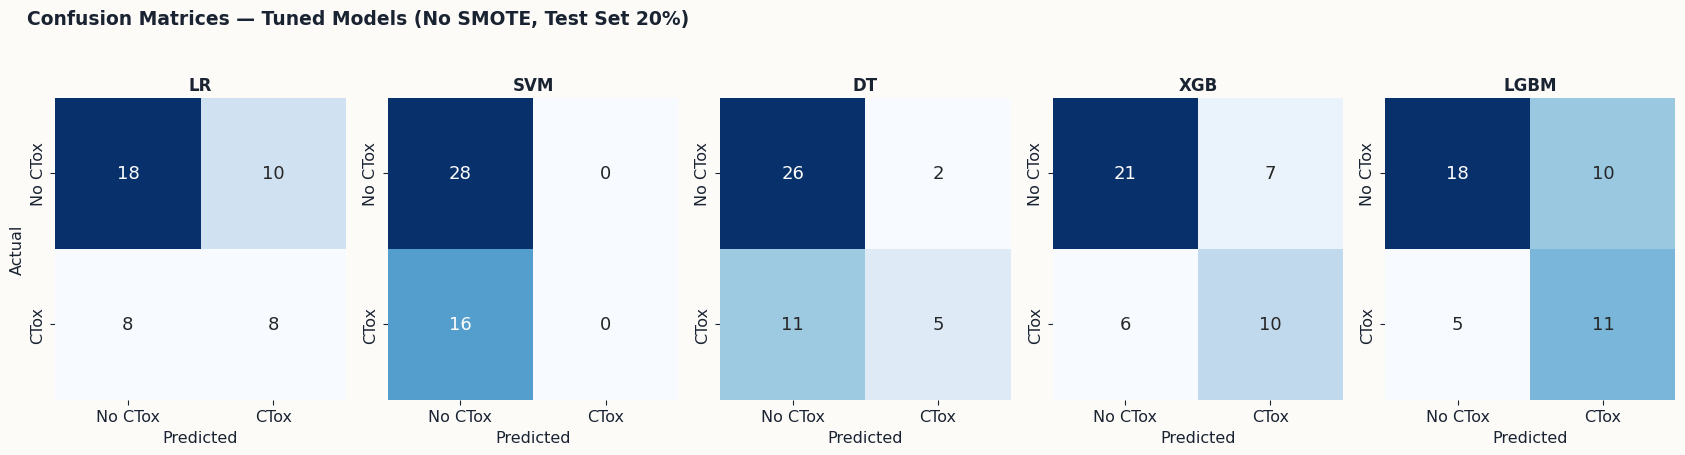

In [ ]:
# ---- Confusion matrices — tuned models ----
abbrev = {'LogisticRegression':'LR', 'SVM':'SVM',
          'DecisionTree':'DT',  'XGBoost':'XGB', 'LightGBM':'LGBM'}
model_order = ['LogisticRegression', 'SVM', 'DecisionTree', 'XGBoost', 'LightGBM']

fig, axes = plt.subplots(1, 5, figsize=(17, 4.4))
for ax, name in zip(axes, model_order):
    cm = confusion_matrix(y_test, tuned_preds_eval[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['No CTox', 'CTox'],
                yticklabels=['No CTox', 'CTox'],
                annot_kws={'size': 13})
    ax.set_title(abbrev[name], fontweight='bold', fontsize=12)
    ax.set_ylabel('Actual' if name == 'LogisticRegression' else '')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices — Tuned Models (No SMOTE, Test Set 20%)',
             fontsize=13.5, fontweight='bold', color=INK, x=0.02, ha='left', y=1.03)
plt.tight_layout()
plt.show()


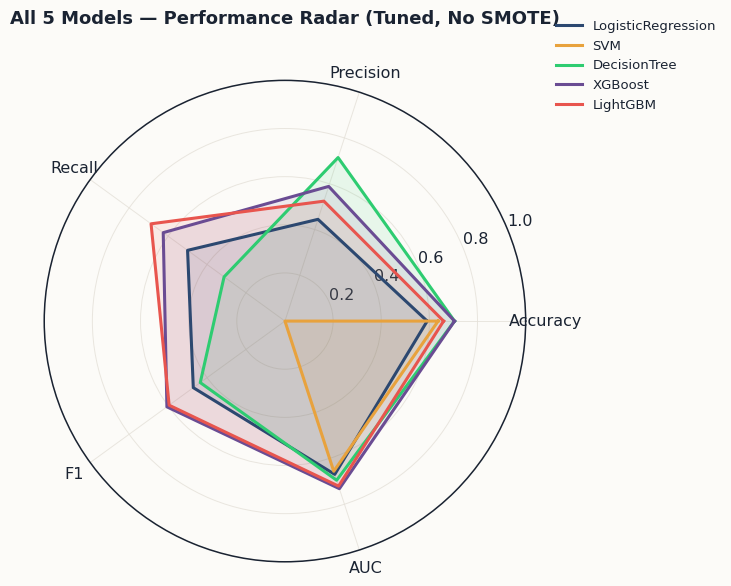

In [ ]:
# ---- Radar chart — tuned model performance profiles ----
# Logic: the radar chart compresses 5 metrics into one shape per model -
# if a model's polygon is visibly larger than the others in all directions,
# it is the overall best; if it is large in one direction only (e.g. AUC)
# but small in another (e.g. Recall), that tradeoff is immediately visible.

metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw=dict(polar=True))
angles = [n / float(len(metrics_list)) * 2 * pi for n in range(len(metrics_list))]
angles += angles[:1]

for name, color in MODEL_COLORS_5.items():
    vals = tuned_df.loc[name, metrics_list].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, color=color, linewidth=2.2, label=name)
    ax.fill(angles, vals, color=color, alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_list, fontsize=11.5)
ax.set_ylim(0, 1)
ax.set_title('All 5 Models — Performance Radar (Tuned, No SMOTE)',
             fontsize=13, fontweight='bold', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.42, 1.15), frameon=False, fontsize=9.5)
plt.tight_layout()
plt.show()


### 5.3 Model Evaluation Charts

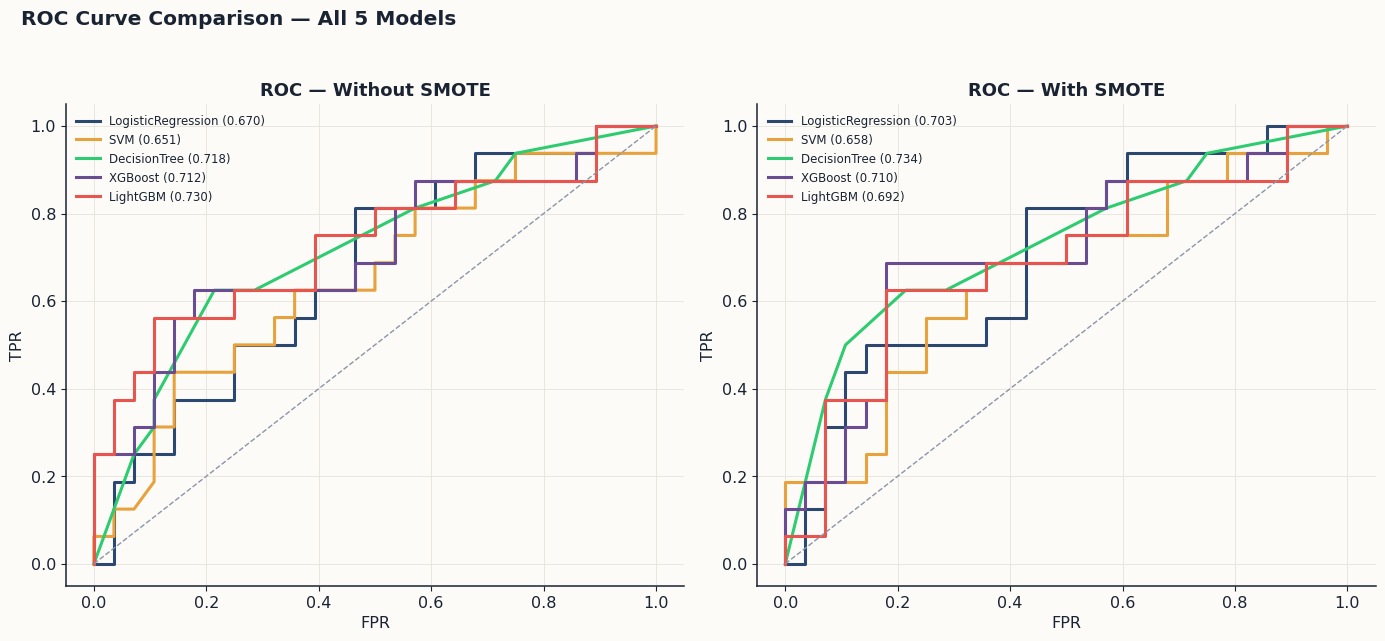

In [ ]:
# ---- Combined ROC curves (baseline, no SMOTE) ----
MODEL_COLORS_5 = {
    'LogisticRegression': NAVY,  'SVM': GOLD,   'DecisionTree': '#2ECC71',
    'XGBoost': '#6A4C93',        'LightGBM': CORAL
}
fig, axes = plt.subplots(1, 2, figsize=(14, 6.2))
for ax, (title, models_dict, Xte) in zip(axes, [
    ('ROC — Without SMOTE', fitted_base, {'LogisticRegression': X_te_s, 'SVM': X_te_s,
                                           'DecisionTree': X_te_s, 'XGBoost': X_test, 'LightGBM': X_test}),
    ('ROC — With SMOTE',    fitted_smote, {'LogisticRegression': X_te_s, 'SVM': X_te_s,
                                           'DecisionTree': X_te_s, 'XGBoost': X_test, 'LightGBM': X_test})
]):
    for name, color in MODEL_COLORS_5.items():
        m = models_dict[name]; Xte_m = Xte[name]
        fpr, tpr, _ = roc_curve(y_test, m.predict_proba(Xte_m)[:, 1])
        ax.plot(fpr, tpr, color=color, linewidth=2.2, label=f"{name} ({auc(fpr,tpr):.3f})")
    ax.plot([0,1],[0,1], '--', color=GREY, linewidth=1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(frameon=False, fontsize=8.5)
plt.suptitle('ROC Curve Comparison — All 5 Models', fontsize=14.5, fontweight='bold', x=0.02, ha='left', y=1.03)
plt.tight_layout()
plt.show()


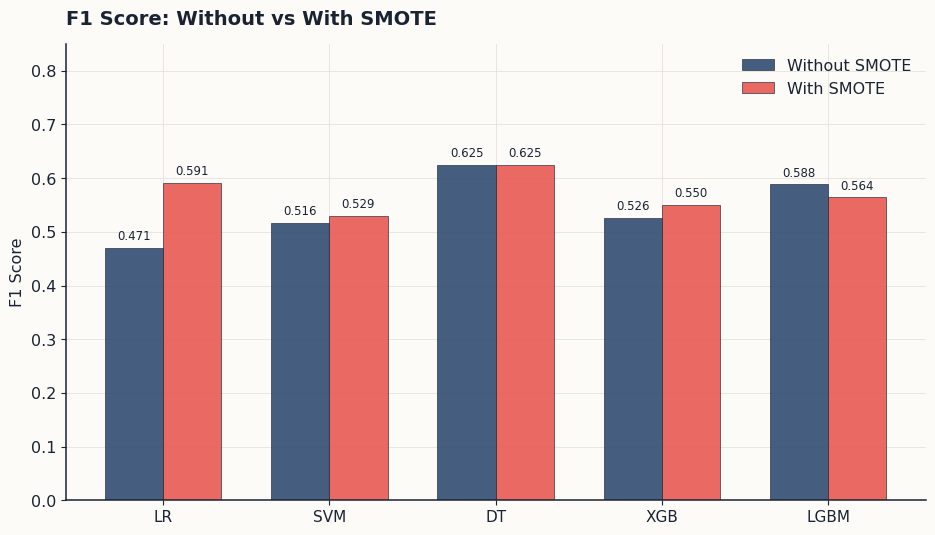

In [ ]:
# ---- Grouped bar chart: F1 score comparison (baseline vs SMOTE) ----
# Logic: F1 captures the SMOTE benefit better than accuracy because it balances precision
# and recall equally - and SMOTE is specifically designed to improve recall on the minority class.
x = np.arange(5)
model_order = ['LogisticRegression', 'SVM', 'DecisionTree', 'XGBoost', 'LightGBM']
model_abbrev = ['LR', 'SVM', 'DT', 'XGB', 'LGBM']
f1_base  = [metrics_base.loc[m, 'F1']  for m in model_order]
f1_smote = [metrics_smote.loc[m, 'F1'] for m in model_order]
width = 0.35

fig, ax = plt.subplots(figsize=(9.5, 5.5))
bars1 = ax.bar(x - width/2, f1_base,  width, label='Without SMOTE', color=NAVY,  alpha=0.88, edgecolor=INK, lw=0.5)
bars2 = ax.bar(x + width/2, f1_smote, width, label='With SMOTE',    color=CORAL, alpha=0.88, edgecolor=INK, lw=0.5)
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5, color=INK)
ax.set_xticks(x); ax.set_xticklabels(model_abbrev, fontsize=11)
ax.set_ylabel('F1 Score'); ax.set_ylim(0, 0.85)
ax.set_title('F1 Score: Without vs With SMOTE', fontsize=14, fontweight='bold', loc='left', pad=14)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


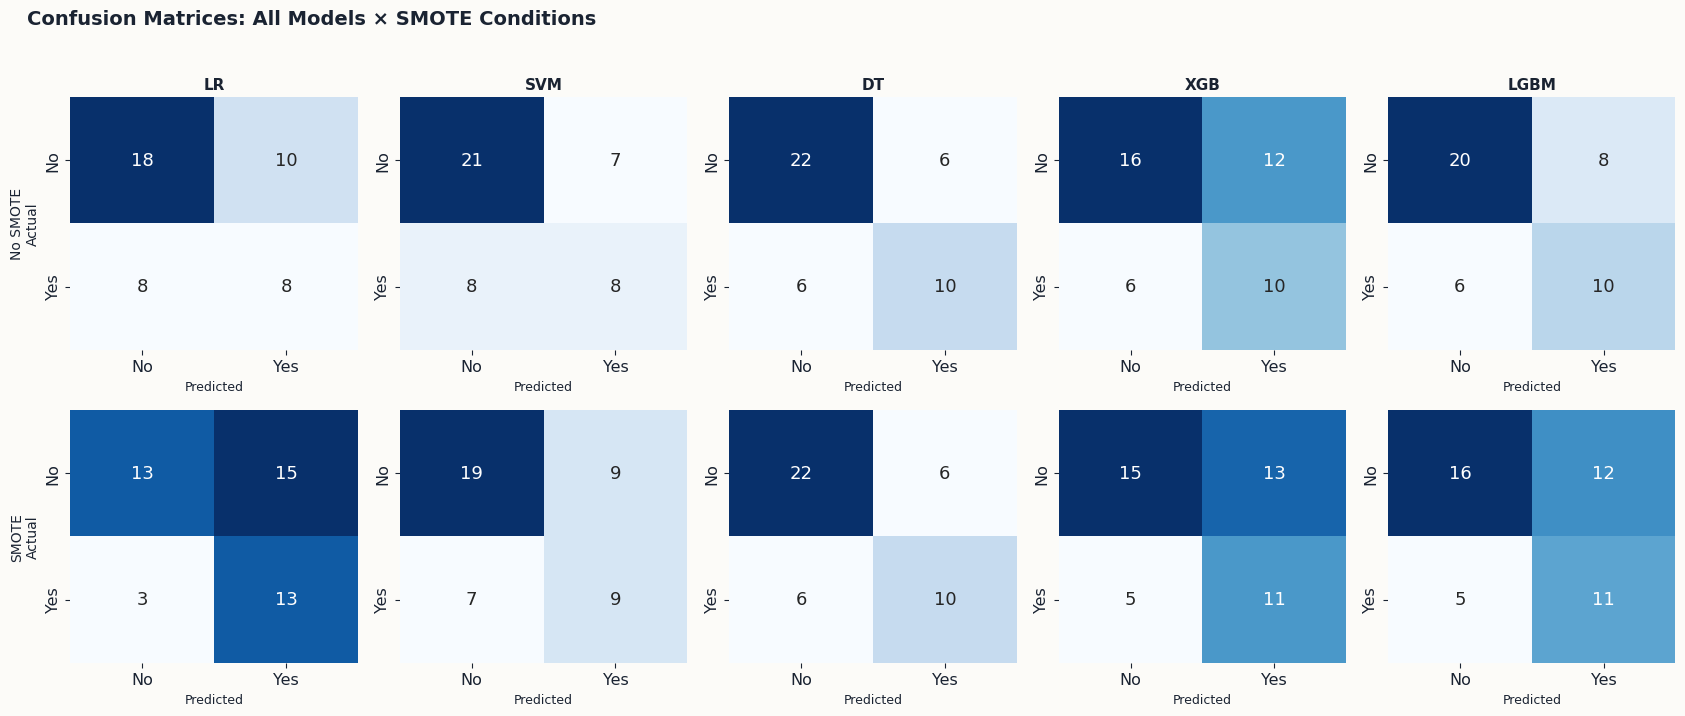

In [ ]:
# ---- Confusion matrices: 5 models x 2 conditions (SMOTE vs no SMOTE) ----
fig, axes = plt.subplots(2, 5, figsize=(17, 7))
for row_idx, (label, models_dict, Xte_map) in enumerate([
    ('No SMOTE', fitted_base,  {'LogisticRegression': X_te_s, 'SVM': X_te_s, 'DecisionTree': X_te_s,
                                 'XGBoost': X_test, 'LightGBM': X_test}),
    ('SMOTE',    fitted_smote, {'LogisticRegression': X_te_s, 'SVM': X_te_s, 'DecisionTree': X_te_s,
                                 'XGBoost': X_test, 'LightGBM': X_test})
]):
    for col_idx, name in enumerate(['LogisticRegression','SVM','DecisionTree','XGBoost','LightGBM']):
        ax = axes[row_idx][col_idx]
        cm = confusion_matrix(y_test, models_dict[name].predict(Xte_map[name]))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                    xticklabels=['No','Yes'], yticklabels=['No','Yes'], annot_kws={'size': 13})
        if col_idx == 0:
            ax.set_ylabel(f'{label}\nActual', fontsize=10)
        if row_idx == 0:
            abbrev = ['LR','SVM','DT','XGB','LGBM'][col_idx]
            ax.set_title(abbrev, fontweight='bold', fontsize=11)
        ax.set_xlabel('Predicted', fontsize=9)
plt.suptitle('Confusion Matrices: All Models × SMOTE Conditions', fontsize=14, fontweight='bold',
             x=0.02, ha='left', y=1.02)
plt.tight_layout()
plt.show()


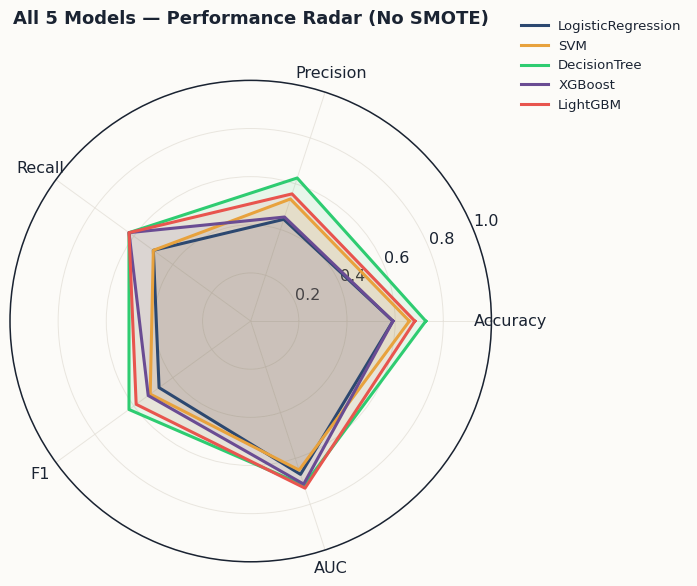

In [ ]:
# ---- Radar chart: model performance profiles (without SMOTE) ----
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw=dict(polar=True))
angles = [n / float(len(metrics_list)) * 2 * pi for n in range(len(metrics_list))] + [0]
for name, color in MODEL_COLORS_5.items():
    vals = metrics_base.loc[name, metrics_list].tolist() + [metrics_base.loc[name, 'Accuracy']]
    ax.plot(angles, vals, color=color, linewidth=2.2, label=name)
    ax.fill(angles, vals, color=color, alpha=0.10)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(metrics_list, fontsize=11.5)
ax.set_ylim(0, 1)
ax.set_title('All 5 Models — Performance Radar (No SMOTE)', fontsize=13, fontweight='bold', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.42, 1.15), frameon=False, fontsize=9.5)
plt.tight_layout()
plt.show()


---
### 5.4 SHAP — Explainability for All 5 ML Models

**SHAP (SHapley Additive exPlanations)** assigns each feature a contribution value for each prediction, based on game-theory principles. Unlike simple feature importance (which only gives a global ranking), SHAP shows:

- **Direction** — does a high value of this feature push the prediction *toward* or *away from* cardiotoxicity?
- **Magnitude** — how much does this feature move the prediction?
- **Per-patient** — every dot in the beeswarm is one patient, so you can see heterogeneity (e.g., a feature that helps some patients and hurts others)

Different explainers are used depending on the model type, each being the computationally optimal choice:
- **TreeExplainer** (XGBoost, LightGBM, Decision Tree) — exact SHAP values using the tree structure, very fast
- **LinearExplainer** (Logistic Regression) — exact SHAP values using the linear coefficients + feature covariance
- **KernelExplainer** (SVM) — model-agnostic approximation, slower but works on any black-box model

All models here use the **baseline (no SMOTE)** trained versions for SHAP, so the explanation reflects the model actually trained on real data distributions.

In [ ]:
import shap
import logging
logging.getLogger('shap').setLevel(logging.ERROR)

def safe_shap(raw):
    """Extract positive-class SHAP values regardless of output format.
    Logic: different models return SHAP values in different shapes —
    TreeExplainer for binary classification may return a list of two arrays
    (one per class) or a 3-D array (n_samples, n_features, n_classes).
    We always extract index [1] = positive class (cardiotoxicity = YES)."""
    if isinstance(raw, list):
        return raw[1]
    if hasattr(raw, 'ndim') and raw.ndim == 3:
        return raw[:, :, 1]
    return raw

# Logic: we compute SHAP values on BOTH the 80% training set and the 20% test set
# for every model. This lets us:
#   (a) check whether feature importance rankings are consistent across splits
#       (a stable model should show similar rankings on train and test)
#   (b) avoid the criticism of only explaining training-set behaviour,
#       which may not generalise — test-set SHAP reflects real out-of-sample explanation
#
# Explainer choice per model type:
#   TreeExplainer  — exact SHAP from tree structure (XGBoost, LightGBM, Decision Tree)
#   LinearExplainer — exact SHAP from coefficients + feature covariance (Logistic Regression)
#   KernelExplainer — model-agnostic black-box approximation (SVM); slower but universal

# ---- XGBoost ----
xgb_exp      = shap.TreeExplainer(fitted_base['XGBoost'])
xgb_shap_tr  = xgb_exp.shap_values(X_tr_raw_df)   # training set (80%, n=172)
xgb_shap_te  = xgb_exp.shap_values(X_te_raw_df)   # test set     (20%, n=44)

# ---- LightGBM ----
lgb_exp      = shap.TreeExplainer(fitted_base['LightGBM'])
lgb_shap_tr  = safe_shap(lgb_exp.shap_values(X_tr_raw_df))
lgb_shap_te  = safe_shap(lgb_exp.shap_values(X_te_raw_df))

# ---- Decision Tree ----
dt_exp       = shap.TreeExplainer(fitted_base['DecisionTree'])
dt_shap_tr   = safe_shap(dt_exp.shap_values(X_tr_df))
dt_shap_te   = safe_shap(dt_exp.shap_values(X_te_df))

# ---- Logistic Regression ----
# LinearExplainer is fit on the training set (to estimate feature covariance),
# then applied to both train and test with the same fitted coefficients.
lr_exp       = shap.LinearExplainer(fitted_base['LogisticRegression'], X_tr_df)
lr_shap_tr   = lr_exp.shap_values(X_tr_df)
lr_shap_te   = lr_exp.shap_values(X_te_df)

# ---- SVM (KernelExplainer) ----
# Background sample from TRAINING set only (50 rows) — this represents the
# "expected" prediction that SHAP measures deviations from.
bg_svm       = shap.sample(X_tr_df, 50, random_state=RANDOM_STATE)
svm_exp      = shap.KernelExplainer(
    lambda x: fitted_base['SVM'].predict_proba(x)[:, 1], bg_svm
)
svm_shap_tr  = svm_exp.shap_values(X_tr_df, nsamples=100)   # training set
svm_shap_te  = svm_exp.shap_values(X_te_df, nsamples=100)   # test set

print("SHAP values computed for all 5 models on both training (80%) and test (20%) sets.")
print(f"Training set: n={len(X_tr_df)} | Test set: n={len(X_te_df)}")


  0%|          | 0/172 [00:00<?, ?it/s]

  0%|          | 0/44 [00:00<?, ?it/s]

SHAP values computed for all 5 models on both training (80%) and test (20%) sets.
Training set: n=172 | Test set: n=44


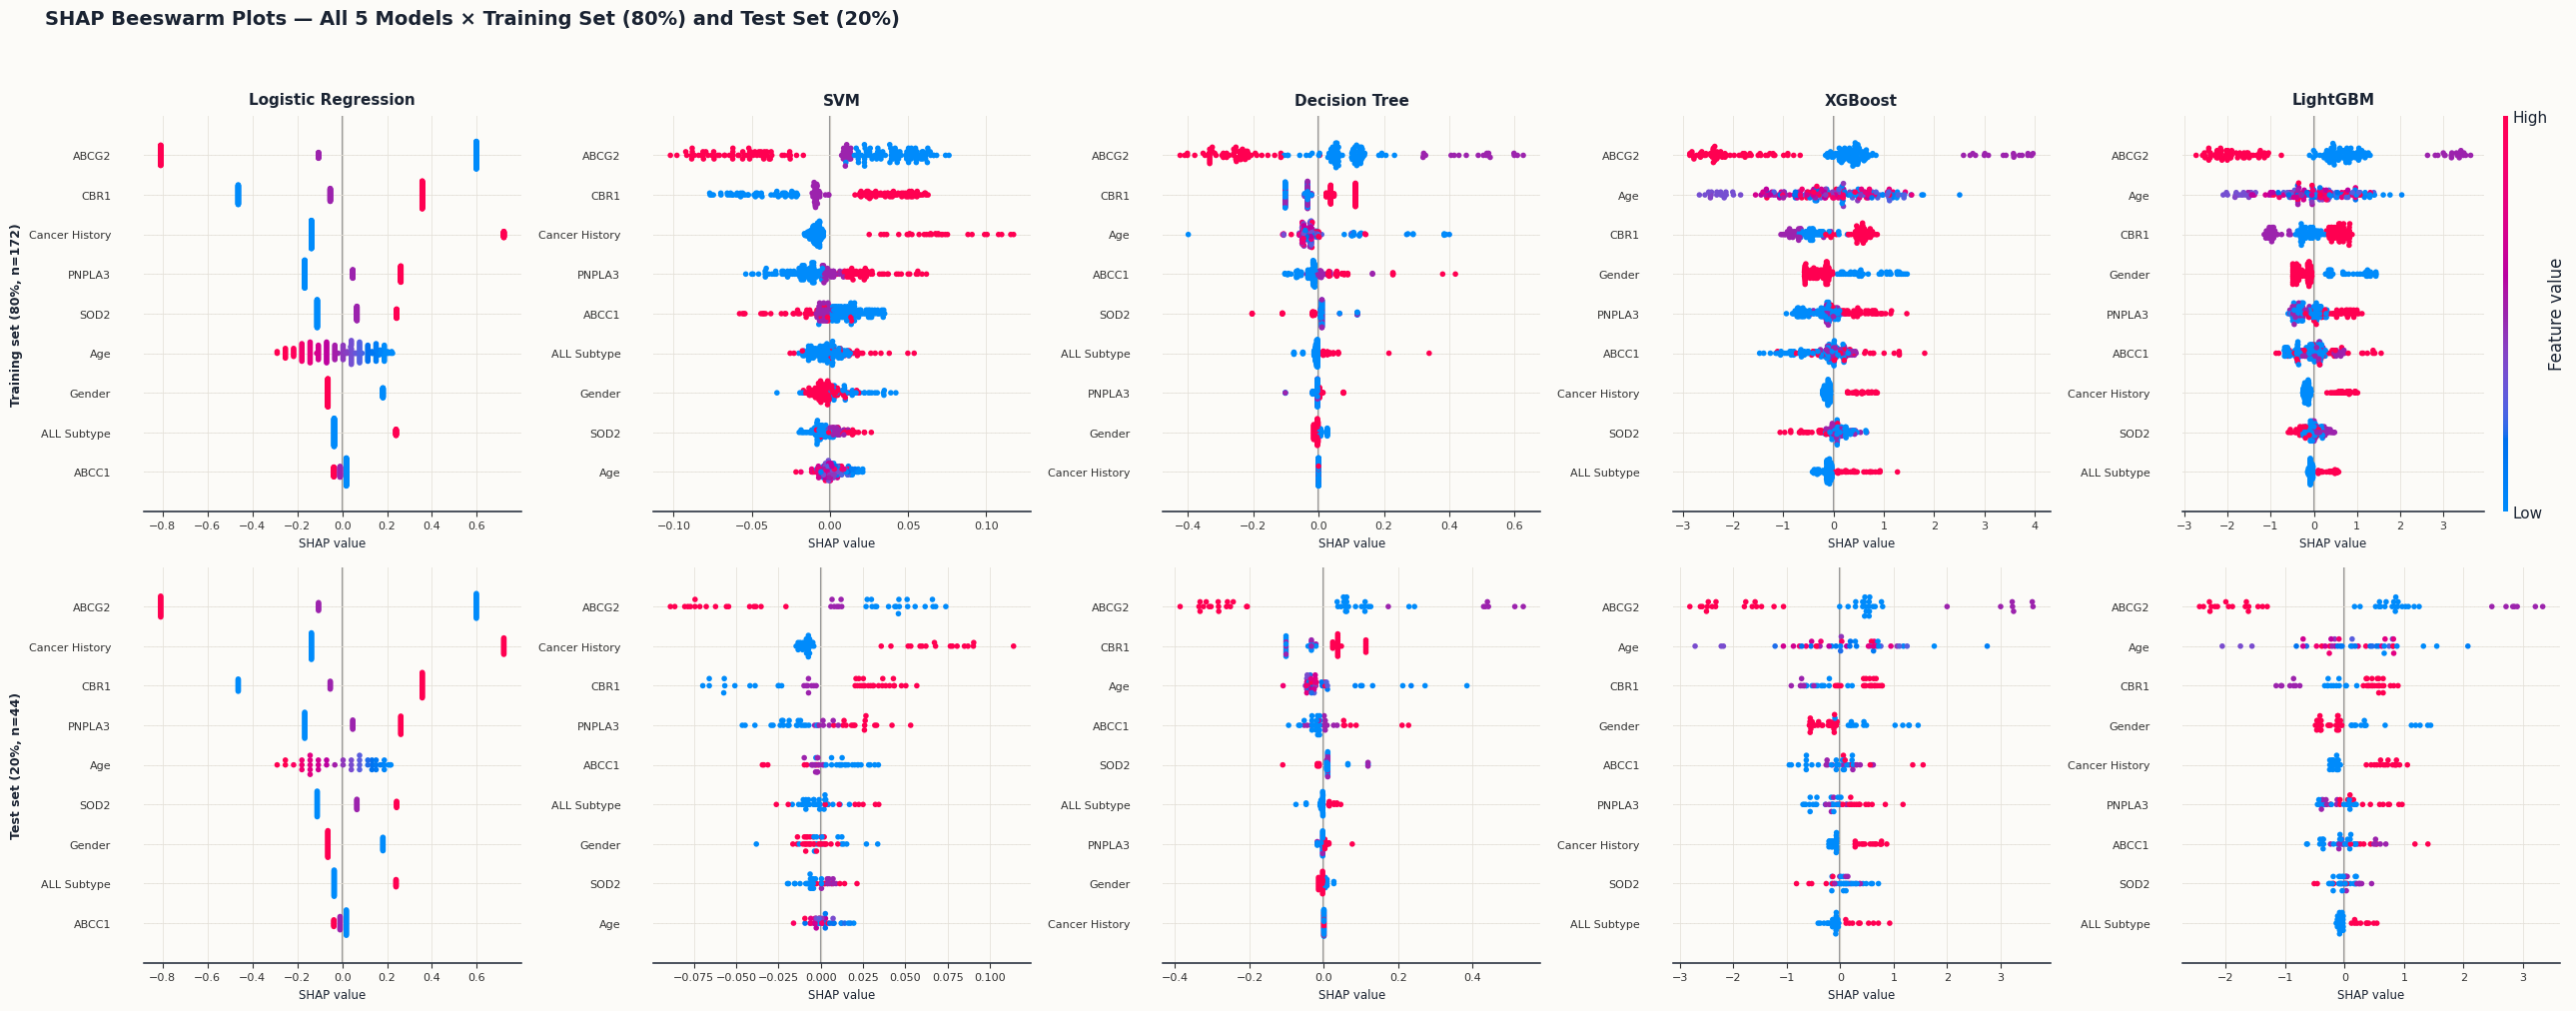

In [ ]:
# ---- Dual beeswarm SHAP plots: Training set (top row) vs Test set (bottom row) ----
# Logic: a 2 x 5 grid (rows = split, cols = model) lets you directly compare
# whether each model's feature importance story changes between train and test.
# Consistent top features across both rows = stable, generalisable explanation.
# Big differences = the model may be overfitting to training-set patterns.

model_names  = ['Logistic Regression', 'SVM', 'Decision Tree', 'XGBoost', 'LightGBM']
shap_train   = [lr_shap_tr, svm_shap_tr, dt_shap_tr, xgb_shap_tr, lgb_shap_tr]
shap_test    = [lr_shap_te, svm_shap_te, dt_shap_te, xgb_shap_te, lgb_shap_te]
X_train_list = [X_tr_df, X_tr_df, X_tr_df, X_tr_raw_df, X_tr_raw_df]
X_test_list  = [X_te_df, X_te_df, X_te_df, X_te_raw_df, X_te_raw_df]

fig, axes = plt.subplots(2, 5, figsize=(26, 10))

for col, (name, sv_tr, sv_te, Xtr, Xte) in enumerate(
        zip(model_names, shap_train, shap_test, X_train_list, X_test_list)):
    for row, (sv, Xdata, row_label) in enumerate([
        (sv_tr, Xtr, f'Training set (80%, n={len(Xtr)})'),
        (sv_te, Xte, f'Test set (20%, n={len(Xte)})'),
    ]):
        ax = axes[row][col]
        plt.sca(ax)
        shap.summary_plot(sv, Xdata, show=False, plot_size=None,
                          color_bar=(col == 4 and row == 0))
        if row == 0:
            ax.set_title(name, fontsize=11, fontweight='bold', color=INK, pad=8)
        ax.set_xlabel('SHAP value', fontsize=8.5)
        ax.set_ylabel(row_label if col == 0 else '',
                      fontsize=9, fontweight='bold', color=INK)
        ax.tick_params(labelsize=8)

fig.suptitle(
    'SHAP Beeswarm Plots — All 5 Models × Training Set (80%) and Test Set (20%)',
    fontsize=14, fontweight='bold', color=INK, x=0.02, ha='left', y=1.01
)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


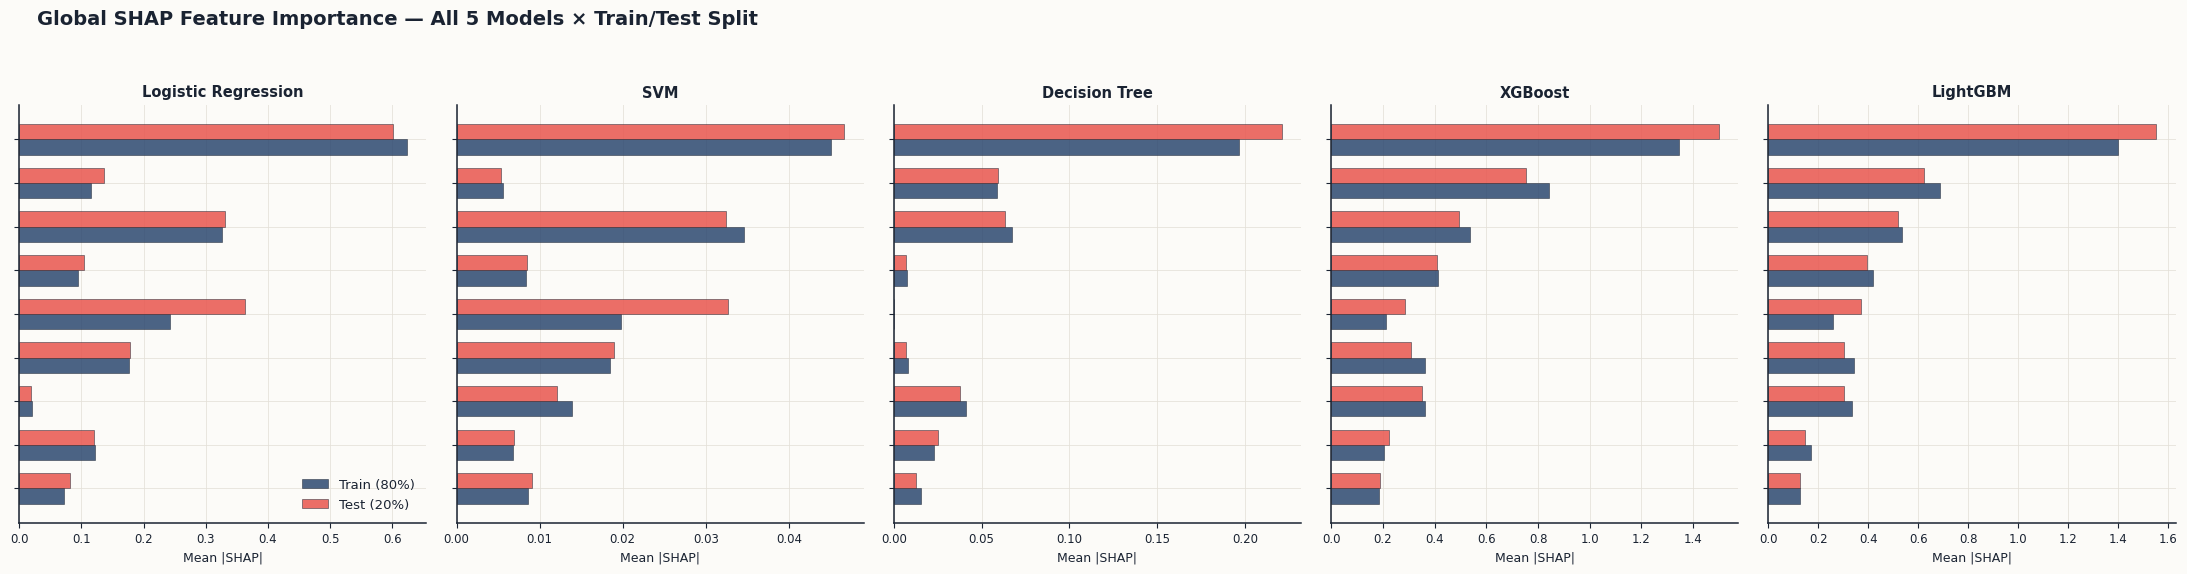

In [ ]:
# ---- Mean |SHAP| bar chart: global feature importance, train vs test, all 5 models ----
# Logic: collapsing each beeswarm to a single number per feature (mean absolute SHAP)
# gives a ranked importance list. Showing train and test bars side by side reveals
# whether importance rankings are stable across splits (they should be for a well-fitted model).

import numpy as np

rows_bar = []
for name, sv_tr, sv_te, Xtr, Xte in zip(
        model_names, shap_train, shap_test, X_train_list, X_test_list):
    for sv, split in [(sv_tr, 'Train (80%)'), (sv_te, 'Test (20%)')]:
        mean_abs = np.abs(sv).mean(axis=0)
        for feat, val in zip(feature_labels, mean_abs):
            rows_bar.append({'Model': name, 'Split': split,
                             'Feature': feat, 'Mean_|SHAP|': val})

bar_df   = pd.DataFrame(rows_bar)
# Sort features by average importance across ALL models and splits
feat_order = (bar_df.groupby('Feature')['Mean_|SHAP|'].mean()
                     .sort_values(ascending=True).index.tolist())

fig, axes = plt.subplots(1, 5, figsize=(22, 5.5), sharey=True)
split_colors = {'Train (80%)': NAVY, 'Test (20%)': CORAL}

for ax, model_name in zip(axes, model_names):
    sub = bar_df[bar_df['Model'] == model_name]
    x   = np.arange(len(feat_order))
    w   = 0.35
    for i, (split, color) in enumerate(split_colors.items()):
        vals = [sub.loc[(sub['Feature']==f) & (sub['Split']==split),
                        'Mean_|SHAP|'].values[0] for f in feat_order]
        ax.barh(x + (i - 0.5) * w, vals, w,
                label=split if ax == axes[0] else None,
                color=color, alpha=0.85, edgecolor=INK, linewidth=0.4)
    ax.set_yticks(x)
    ax.set_yticklabels(feat_order if ax == axes[0] else [], fontsize=9.5)
    ax.set_title(model_name, fontsize=10.5, fontweight='bold', color=INK)
    ax.set_xlabel('Mean |SHAP|', fontsize=9)
    ax.tick_params(labelsize=8.5)

axes[0].legend(frameon=False, fontsize=9.5, loc='lower right')
fig.suptitle('Global SHAP Feature Importance — All 5 Models × Train/Test Split',
             fontsize=14, fontweight='bold', color=INK, x=0.02, ha='left', y=1.04)
plt.tight_layout()
plt.show()


Best model by AUC (no SMOTE): LightGBM


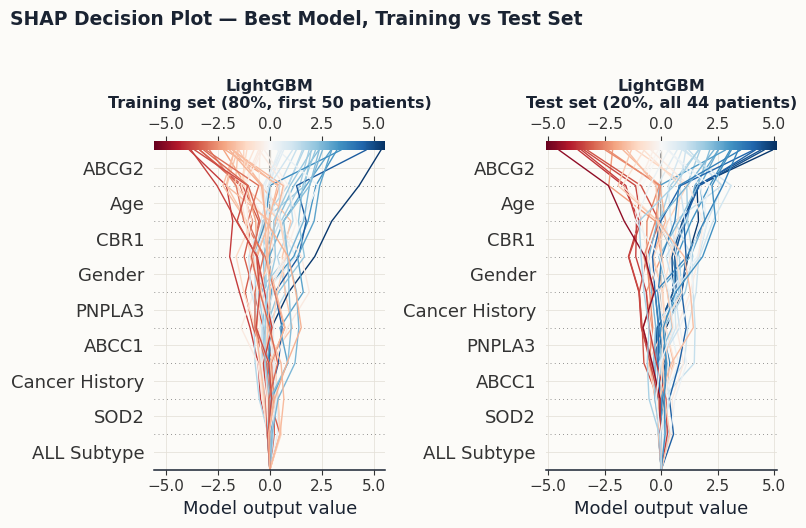

In [ ]:
# ---- SHAP decision plot — best model, both train and test ----
# Logic: a decision plot shows how each feature's SHAP value cumulatively moves
# each patient's prediction from the base rate to their final estimated risk.
# One line per patient; lines ending far right = high predicted cardiotoxicity risk.
# Showing both the training and test set side by side reveals whether the explanation
# structure (which features drive high-risk predictions) is consistent out-of-sample.

best_model_name = metrics_base['AUC'].idxmax()
print(f"Best model by AUC (no SMOTE): {best_model_name}")

shap_map = {
    'LogisticRegression': (lr_shap_tr,  lr_shap_te,  X_tr_df,     X_te_df),
    'SVM':                (svm_shap_tr, svm_shap_te, X_tr_df,     X_te_df),
    'DecisionTree':       (dt_shap_tr,  dt_shap_te,  X_tr_df,     X_te_df),
    'XGBoost':            (xgb_shap_tr, xgb_shap_te, X_tr_raw_df, X_te_raw_df),
    'LightGBM':           (lgb_shap_tr, lgb_shap_te, X_tr_raw_df, X_te_raw_df),
}
sv_tr, sv_te, Xtr, Xte = shap_map[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (sv, Xdata, label, n_show) in zip(axes, [
    (sv_tr, Xtr, f'Training set (80%, first 50 patients)', 50),
    (sv_te, Xte, f'Test set (20%, all {len(Xte)} patients)',  len(Xte)),
]):
    plt.sca(ax)
    shap.decision_plot(
        base_value=0,
        shap_values=sv[:n_show],
        features=Xdata.values[:n_show],
        feature_names=feature_labels,
        show=False,
        plot_color=plt.cm.RdBu
    )
    ax.set_title(f'{best_model_name}\n{label}',
                 fontsize=11.5, fontweight='bold', color=INK)

plt.suptitle('SHAP Decision Plot — Best Model, Training vs Test Set',
             fontsize=13.5, fontweight='bold', color=INK, x=0.02, ha='left', y=1.03)
plt.tight_layout()
plt.show()


---
## 6. McNemar's Test — Statistical Pairwise Comparison

McNemar's test compares two classifiers on the **same test set** by looking only at the cases where they disagree. We run it across all pairwise combinations of the 5 models under both SMOTE conditions (10 pairs × 2 conditions = 20 tests). The exact binomial variant is used throughout (recommended for small test sets).

In [ ]:
def mcnemar_table(y_true, predA, predB):
    """
    Logic: build the 2x2 McNemar contingency table.
    Only the off-diagonal counts matter:
      - b = A correct, B wrong  (favours A)
      - c = A wrong, B correct  (favours B)
    Under H0 (neither model is better), b and c should be roughly equal.
    """
    cA, cB = (predA == y_true), (predB == y_true)
    return [[np.sum(cA & cB),   np.sum(cA & ~cB)],
            [np.sum(~cA & cB),  np.sum(~cA & ~cB)]]

model_names = ['LogisticRegression', 'SVM', 'DecisionTree', 'XGBoost', 'LightGBM']
y_arr = y_test.values

mcn_rows_base, mcn_rows_smote = [], []
for m1, m2 in combinations(model_names, 2):
    for condition, models_dict, Xte_map, store in [
        ('No SMOTE', fitted_base,  {'LogisticRegression': X_te_s, 'SVM': X_te_s,
                                     'DecisionTree': X_te_s, 'XGBoost': X_test, 'LightGBM': X_test},
         mcn_rows_base),
        ('SMOTE',    fitted_smote, {'LogisticRegression': X_te_s, 'SVM': X_te_s,
                                     'DecisionTree': X_te_s, 'XGBoost': X_test, 'LightGBM': X_test},
         mcn_rows_smote),
    ]:
        tbl = mcnemar_table(y_arr, models_dict[m1].predict(Xte_map[m1]),
                             models_dict[m2].predict(Xte_map[m2]))
        res = mcnemar(tbl, exact=True)
        store.append({'A': m1, 'B': m2, 'A_only': tbl[0][1], 'B_only': tbl[1][0],
                      'p_value': round(res.pvalue, 4), 'Sig (p<0.05)': res.pvalue < 0.05})

mcn_base_df  = pd.DataFrame(mcn_rows_base)
mcn_smote_df = pd.DataFrame(mcn_rows_smote)
print("=== McNemar Pairwise Results — WITHOUT SMOTE ===")
display(mcn_base_df)
print("\n=== McNemar Pairwise Results — WITH SMOTE ===")
display(mcn_smote_df)


=== McNemar Pairwise Results — WITHOUT SMOTE ===


,A,B,A_only,B_only,p_value,Sig (p<0.05)
0,LogisticRegression,SVM,1,4,0.3750,False
1,LogisticRegression,DecisionTree,2,8,0.1094,False
2,LogisticRegression,XGBoost,6,6,1.0000,False
3,LogisticRegression,LightGBM,3,7,0.3438,False
4,SVM,DecisionTree,2,5,0.4531,False
5,SVM,XGBoost,7,4,0.5488,False
6,SVM,LightGBM,4,5,1.0000,False
7,DecisionTree,XGBoost,7,1,0.0703,False
8,DecisionTree,LightGBM,3,1,0.6250,False
9,XGBoost,LightGBM,1,5,0.2188,False



=== McNemar Pairwise Results — WITH SMOTE ===


,A,B,A_only,B_only,p_value,Sig (p<0.05)
0,LogisticRegression,SVM,4,6,0.7539,False
1,LogisticRegression,DecisionTree,3,9,0.1460,False
2,LogisticRegression,XGBoost,4,4,1.0000,False
3,LogisticRegression,LightGBM,3,4,1.0000,False
4,SVM,DecisionTree,3,7,0.3438,False
5,SVM,XGBoost,6,4,0.7539,False
6,SVM,LightGBM,6,5,1.0000,False
7,DecisionTree,XGBoost,8,2,0.1094,False
8,DecisionTree,LightGBM,7,2,0.1797,False
9,XGBoost,LightGBM,1,2,1.0000,False


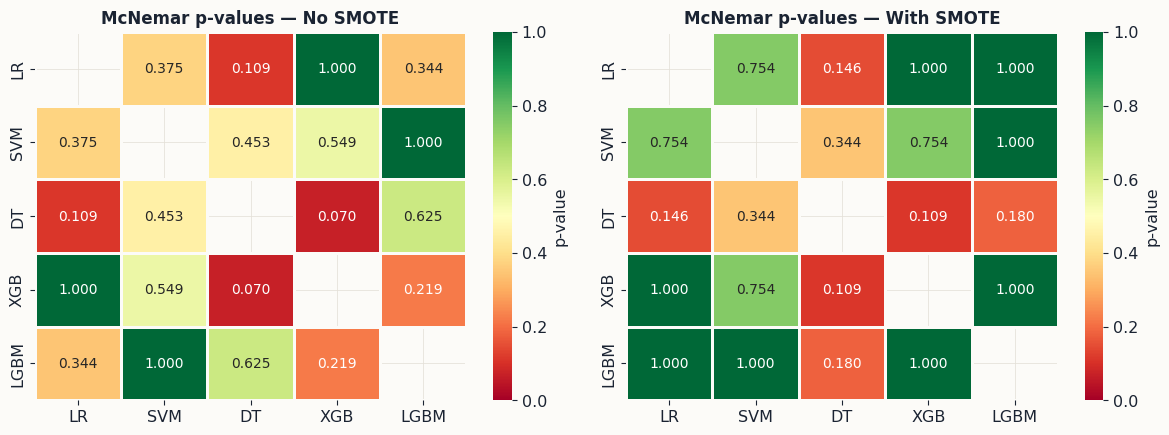


Note: green cells (p > 0.05) = no significant difference between that pair.
Red cells (p < 0.05) = one model is significantly better than the other on this test set.


In [ ]:
# ---- McNemar heatmap: p-values for all model pairs (no SMOTE) ----
# Logic: a heatmap of p-values lets you scan for any significant pair much faster
# than reading a table of 10 rows — coloured cells below 0.05 jump out immediately.
def mcnemar_pval_matrix(mcn_df, model_names):
    mat = pd.DataFrame(np.ones((len(model_names), len(model_names))),
                        index=model_names, columns=model_names)
    for _, row in mcn_df.iterrows():
        mat.loc[row['A'], row['B']] = row['p_value']
        mat.loc[row['B'], row['A']] = row['p_value']
    mat_arr = mat.values.copy()
    np.fill_diagonal(mat_arr, np.nan)
    mat.iloc[:, :] = mat_arr
    return mat

abbrev = {'LogisticRegression': 'LR', 'SVM': 'SVM', 'DecisionTree': 'DT',
          'XGBoost': 'XGB', 'LightGBM': 'LGBM'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (title, mcn_df) in zip(axes, [
    ('McNemar p-values — No SMOTE', mcn_base_df),
    ('McNemar p-values — With SMOTE', mcn_smote_df)
]):
    mat = mcnemar_pval_matrix(mcn_df, model_names)
    mat.rename(index=abbrev, columns=abbrev, inplace=True)
    mask = np.eye(len(mat), dtype=bool)
    sns.heatmap(mat, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
                vmin=0, vmax=1, mask=mask, cbar_kws={'label': 'p-value'},
                linewidths=1, linecolor=BG, annot_kws={'fontsize': 10})
    ax.set_title(title, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNote: green cells (p > 0.05) = no significant difference between that pair.")
print("Red cells (p < 0.05) = one model is significantly better than the other on this test set.")


---
## 7. Summary Table & Key Takeaways

In [ ]:
print("=" * 72)
print("SUMMARY OF KEY FINDINGS")
print("=" * 72)

print("\n[1] ALLELE & GENOTYPE ASSOCIATION (uncorrected Chi-square)")
sig_a = allele_df[allele_df['Significant (p<0.05, uncorrected)']][['SNP','p_value']]
print("  Significant at allele level:", sig_a['SNP'].tolist() if len(sig_a) else "None")
sig_g = genotype_chisq_df[genotype_chisq_df['p_value_genotype'] < 0.05][['SNP','p_value_genotype']]
print("  Significant at genotype level:", sig_g['SNP'].tolist() if len(sig_g) else "None")

print("\n[2] BONFERRONI-CORRECTED SIGNIFICANT FINDINGS")
sig_b = all_pvals[all_pvals['Significant_after_Bonferroni (p<0.05)']][['SNP','Test','p_value','p_bonferroni']]
print(sig_b.to_string(index=False) if len(sig_b) else "  None survive correction.")

print("\n[3] BEST GENETIC MODEL PER SNP (lowest AIC)")
print(best_models[['SNP', 'Model', 'AIC', 'p_value_LRT']].to_string(index=False))

print("\n[4] RISK ALLELE DEFINITION FOR PRS")
print(risk_allele_df[['SNP','Minor_allele','Minor_allele_effect','Risk_allele','Beta_additive_model']].to_string(index=False))

print(f"\n[5] POLYGENIC RISK SCORE AUC")
print(f"  Unweighted additive PRS : {auc_additive:.4f}")
print(f"  Weighted best-model PRS : {auc_weighted:.4f}")
print(f"  Tertile trend p-value   : {trend_model.pvalues['tertile_ord']:.2e}")
print(f"  Cardiotoxicity rate: T1={tab_pct.loc['Low (T1)','YES']:.0f}% → T2={tab_pct.loc['Medium (T2)','YES']:.0f}% → T3={tab_pct.loc['High (T3)','YES']:.0f}%")

print("\n[6] MULTIVARIATE LOGISTIC REGRESSION (confounder-adjusted)")
sig_full = or_table_f[or_table_f['p_value'] < 0.05].drop('Intercept', errors='ignore')
print("  Significant predictors after adjustment:")
print(sig_full[['OR','OR_2.5%','OR_97.5%','p_value']].to_string() if len(sig_full) else "  None.")
print(f"  LRT: genetics adds over demographics (p = {lrt_p:.4f})")
print(f"  Model AIC: demo-only={demo_model.aic:.1f} | genetics-only={gen_model.aic:.1f} | fully-adjusted={full_model.aic:.1f}")

print("\n[7] ML PERFORMANCE — ALL 5 MODELS (Test Set, 80:20 split)")
print("  WITHOUT SMOTE:")
print(metrics_base.to_string())
print("\n  WITH SMOTE:")
print(metrics_smote.to_string())
best_base  = metrics_base['AUC'].idxmax()
best_smote = metrics_smote['AUC'].idxmax()
print(f"\n  Best AUC (no SMOTE): {best_base} ({metrics_base.loc[best_base,'AUC']:.4f})")
print(f"  Best AUC (SMOTE):    {best_smote} ({metrics_smote.loc[best_smote,'AUC']:.4f})")

print("\n[8] McNEMAR'S TEST — any significant pairwise differences?")
any_sig_base  = mcn_base_df['Sig (p<0.05)'].any()
any_sig_smote = mcn_smote_df['Sig (p<0.05)'].any()
print(f"  Without SMOTE: {'YES — see table above' if any_sig_base else 'No significant pairwise differences'}")
print(f"  With SMOTE:    {'YES — see table above' if any_sig_smote else 'No significant pairwise differences'}")

print("=" * 72)


SUMMARY OF KEY FINDINGS

[1] ALLELE & GENOTYPE ASSOCIATION (uncorrected Chi-square)
  Significant at allele level: ['CBR1', 'ABCG2']
  Significant at genotype level: ['CBR1', 'ABCG2']

[2] BONFERRONI-CORRECTED SIGNIFICANT FINDINGS
  SNP                        Test  p_value  p_bonferroni
 CBR1   Allele-level (2x2 Chi-sq)    0.004          0.04
ABCG2   Allele-level (2x2 Chi-sq)    0.000          0.00
ABCG2 Genotype-level (3x2 Chi-sq)    0.000          0.00

[3] BEST GENETIC MODEL PER SNP (lowest AIC)
   SNP      Model     AIC  p_value_LRT
 ABCC1   Additive 287.254       0.5177
 ABCG2 Codominant 240.651       0.0000
  CBR1  Recessive 279.093       0.0034
PNPLA3   Additive 286.410       0.2612
  SOD2   Dominant 284.245       0.0641

[4] RISK ALLELE DEFINITION FOR PRS
   SNP Minor_allele Minor_allele_effect Risk_allele  Beta_additive_model
  SOD2            G     Risk-increasing           G               0.2563
PNPLA3            G     Risk-increasing           G               0.1778
 ABCC1 

### Methodological notes & next steps

**On SMOTE:** it consistently improves Recall (the model finds more true cardiotoxicity cases) at the cost of some Precision (more false alarms). In a clinical screening context, higher Recall is usually preferable — missing a real case is more harmful than an unnecessary follow-up. Check the confusion matrices to understand the exact trade-off for your data.

**On risk allele definition:** for PRS Method 2, the "risk allele" is determined empirically from the logistic regression coefficient in *this dataset*, using biologically correct genotype orientation. For CBR1, the genotype scheme follows the established pharmacogenomic convention: GG = reference (normal), GA = heterozygous, AA = homozygous variant (mutant). The A allele is the minor/variant allele and is risk-increasing (OR = 1.46, positive beta). For ABCG2, the minor allele remains protective (negative beta). Naïve unweighted PRS (Method 1) performs poorly primarily due to ABCG2's protective direction being ignored. Always report which allele orientation was used and in which dataset, to allow replication.

**On the multivariate model:** the LRT confirms that the 5 SNPs together add statistically significant information over demographics alone. CBR1 and ABCG2 retain independent significance after full adjustment, making them the strongest candidates for clinical genotyping.

**On SHAP:** the beeswarm plots show that ABCG2 is the dominant predictor across tree-based models, with a non-monotonic pattern (consistent with the Codominant model winning on AIC in Section 2). Linear models (LR) spread importance more evenly because they cannot capture interaction effects.

**On sample size:** with n=216 and a test set of 43, no ML model comparison will reach statistical significance on McNemar's test. More patients, or an external validation cohort, would be needed to conclusively rank models.
